<a href="https://colab.research.google.com/github/PENUMARTHIHIMAVARSHINI/Dementia-/blob/main/Speech_processing_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# convert to 16khz .wav and extract only patient audio

In [ ]:
from pathlib import Path
from pydub import AudioSegment
import os

# 📁 INPUT (GitHub repo)
REPO_ROOT = Path("/content/Dementia-/dementia")

# 📁 OUTPUT (Google Drive ✅)
DRIVE_ROOT = "/content/drive/MyDrive"
OUTPUT_ROOT = Path(DRIVE_ROOT) / "preprocessed_audio"

# Tasks in repo
TASKS = ["cookie"]

def convert_mp3_to_wav(src_path, dst_path, target_sr=16000):
    audio = AudioSegment.from_mp3(src_path)
    audio = audio.set_frame_rate(target_sr).set_channels(1)
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)
    audio.export(dst_path, format="wav")

converted, skipped, failed = 0, 0, []

for task in TASKS:

    # ✅ INPUT from GitHub
    src_base = REPO_ROOT / task / "processed_audios"

    # ✅ OUTPUT to Drive (same as your original structure)
    dst_base = OUTPUT_ROOT /"dementia"/ task / "wav"

    print(f"\n🔍 Checking: {src_base}")

    if not src_base.exists():
        print(f"[SKIP] {task} — folder not found")
        continue

    for session_dir in sorted(src_base.iterdir()):
        if not session_dir.is_dir():
            continue

        for mp3 in session_dir.glob("*.mp3"):
            dst_wav = dst_base / session_dir.name / (mp3.stem + ".wav")

            if dst_wav.exists():
                skipped += 1
                continue

            try:
                convert_mp3_to_wav(str(mp3), str(dst_wav))
                converted += 1
                print(f"[OK] {task}/{session_dir.name}")

            except Exception as e:
                failed.append(str(mp3))
                print(f"[FAIL] {mp3.name} — {e}")

print(f"\n✅ Done. Converted: {converted} | Skipped: {skipped} | Failed: {len(failed)}")


🔍 Checking: /content/Dementia-/dementia/cookie/processed_audios
[OK] cookie/001-0
[OK] cookie/001-2
[OK] cookie/003-0
[OK] cookie/005-0
[OK] cookie/005-2
[OK] cookie/007-1
[OK] cookie/007-3
[OK] cookie/010-0
[OK] cookie/010-1
[OK] cookie/010-2
[OK] cookie/010-3
[OK] cookie/010-4
[OK] cookie/014-2
[OK] cookie/016-0
[OK] cookie/016-1
[OK] cookie/016-3
[OK] cookie/016-4
[OK] cookie/018-0
[OK] cookie/023-0
[OK] cookie/023-2
[OK] cookie/024-1
[OK] cookie/024-2
[OK] cookie/029-0
[OK] cookie/029-1
[OK] cookie/030-0
[OK] cookie/030-1
[OK] cookie/033-0
[OK] cookie/033-1
[OK] cookie/033-2
[OK] cookie/033-3
[OK] cookie/033-4
[OK] cookie/035-0
[OK] cookie/035-1
[OK] cookie/039-0
[OK] cookie/043-0
[OK] cookie/046-0
[OK] cookie/046-2
[OK] cookie/049-0
[OK] cookie/049-1
[OK] cookie/050-0
[OK] cookie/051-0
[OK] cookie/051-1
[OK] cookie/051-2
[OK] cookie/051-3
[OK] cookie/053-1
[OK] cookie/057-0
[OK] cookie/057-1
[OK] cookie/057-2
[OK] cookie/058-0
[OK] cookie/058-1
[OK] cookie/058-3
[OK] cookie/058-4

# New Section

## extracting patient only audio

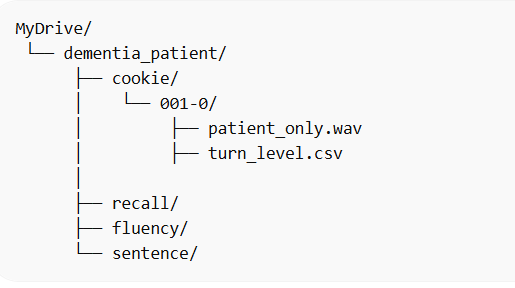

In [ ]:
!git clone https://github.com/PENUMARTHIHIMAVARSHINI/Dementia-.git

Cloning into 'Dementia-'...
remote: Enumerating objects: 5046, done.
remote: Counting objects: 100% (1910/1910), done.
remote: Compressing objects: 100% (1882/1882), done.
remote: Total 5046 (delta 639), reused 0 (delta 0), pack-reused 3136 (from 2)
Receiving objects: 100% (5046/5046), 1.18 GiB | 32.55 MiB/s, done.
Resolving deltas: 100% (1748/1748), done.
Updating files: 100% (4119/4119), done.


In [ ]:
from pathlib import Path
from pydub import AudioSegment
import os
import csv

# 📁 DRIVE (WAV + OUTPUT)
DRIVE_ROOT = Path("/content/drive/MyDrive")

WAV_ROOT = DRIVE_ROOT / "preprocessed_audio"
OUTPUT_ROOT = DRIVE_ROOT / "preprocessed_data"

# 📁 GITHUB (ONLY RTTM)
REPO_ROOT = Path("/content/Dementia-/dementia")

TASKS = ["sentence"]   # change if needed

# 🔧 Safe float
def safe_float(x):
    return float(x.strip().replace(",", ""))

# 🔍 Parse RTTM
def parse_rttm_all_speakers(rttm_path):
    speaker_segments = {}

    with open(rttm_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 8:
                continue

            try:
                start_sec = safe_float(parts[3])
                duration_sec = safe_float(parts[4])
                speaker = parts[7]
            except:
                continue

            start_ms = int(start_sec * 1000)
            dur_ms   = int(duration_sec * 1000)

            speaker_segments.setdefault(speaker, []).append((start_ms, dur_ms))

    return speaker_segments


# 🎧 Extract speakers + CSV
def extract_speakers(wav_path, rttm_path, out_dir):
    speaker_segments = parse_rttm_all_speakers(rttm_path)

    if not speaker_segments:
        print(f"[WARN] Empty RTTM: {rttm_path}")
        return False

    audio = AudioSegment.from_wav(wav_path)
    os.makedirs(out_dir, exist_ok=True)

    # 📄 turn.csv
    csv_path = out_dir / "turn.csv"
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["speaker", "start_ms", "duration_ms"])

        for speaker, segments in speaker_segments.items():
            speaker_audio = AudioSegment.empty()

            for start_ms, dur_ms in segments:
                end_ms = min(start_ms + dur_ms, len(audio))
                speaker_audio += audio[start_ms:end_ms]
                writer.writerow([speaker, start_ms, dur_ms])

            speaker_audio.export(out_dir / f"{speaker}.wav", format="wav")

    return True


# 🔁 MAIN LOOP
processed, skipped, failed = 0, 0, []

for task in TASKS:

    wav_base = WAV_ROOT /"dementia"/ task / "wav"
    rttm_base = REPO_ROOT / task / "processed_audios"
    out_base  = OUTPUT_ROOT / task

    print(f"\n🔍 Checking WAV: {wav_base}")

    if not wav_base.exists():
        print(f"[SKIP] {task} — no WAVs found")
        continue

    for session_dir in sorted(wav_base.iterdir()):
        if not session_dir.is_dir():
            continue

        session_name = session_dir.name

        wav_files = list(session_dir.glob("*.wav"))
        if not wav_files:
            skipped += 1
            continue

        wav_path = wav_files[0]

        # 🔥 RTTM from GitHub
        rttm_folder = rttm_base / session_name
        rttm_files = list(rttm_folder.glob("*.rttm"))

        if not rttm_files:
            print(f"[WARN] No RTTM (GitHub): {session_name}")
            continue

        # prefer exclusive
        rttm_path = None
        for f in rttm_files:
            if "exclusive" in f.name:
                rttm_path = f
                break
        if rttm_path is None:
            rttm_path = rttm_files[0]

        out_dir = out_base / session_name

        # ✅ skip if already done
        if (out_dir / "turn.csv").exists():
            skipped += 1
            continue

        try:
            ok = extract_speakers(wav_path, rttm_path, out_dir)
            if ok:
                processed += 1
                print(f"[OK] {task}/{session_name}")
            else:
                failed.append(session_name)
        except Exception as e:
            failed.append(session_name)
            print(f"[FAIL] {session_name} — {e}")


# 📊 SUMMARY
print("\n✅ DONE")
print(f"Processed: {processed}")
print(f"Skipped: {skipped}")
print(f"Failed: {len(failed)}")

[SKIP] dementia/sentence — no WAVs found

dementia/sentence done.
Extracted: 0 | Skipped: 0 | Failed: 0


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


# normalization

In [ ]:
from pathlib import Path
from pydub import AudioSegment

# 📁 Root folder (change if needed)
ROOT = Path("/content/drive/MyDrive/preprocessed_data/dementia/fluency")

processed, skipped, failed = 0, 0, []

def normalize_audio(in_path, out_path):
    try:
        audio = AudioSegment.from_wav(in_path)

        # ⚠️ skip silent files
        if audio.dBFS == float("-inf"):
            return False, "silent"

        # ✅ normalize
        normalized = audio.apply_gain(-audio.max_dBFS)

        # save as new file
        normalized.export(out_path, format="wav")
        return True, "ok"

    except Exception as e:
        return False, str(e)


# 🔁 Loop through all folders
# 🔁 Loop through ONLY session folders
for session_folder in ROOT.iterdir():

    if not session_folder.is_dir():
        continue

    input_wav = session_folder / "SPEAKER_00.wav"
    output_wav = session_folder / "norm_speaker_00.wav"

    # skip if no speaker_00.wav
    if not input_wav.exists():
        print(f"[SKIP] No speaker_00.wav in {session_folder.name}")
        continue

    # skip if already normalized
    if output_wav.exists():
        skipped += 1
        continue

    ok, msg = normalize_audio(input_wav, output_wav)

    if ok:
        processed += 1
        print(f"[OK] {session_folder.name}")
    elif msg == "silent":
        skipped += 1
    else:
        failed.append(str(input_wav))
        print(f"[FAIL] {input_wav} — {msg}")

# 📊 Summary
print("\n✅ DONE")
print(f"Processed: {processed}")
print(f"Skipped: {skipped}")
print(f"Failed: {len(failed)}")

[OK] 001-0
[OK] 001-2
[OK] 003-0
[OK] 005-0
[OK] 005-2
[OK] 007-1
[OK] 007-3
[OK] 010-0
[OK] 010-1
[OK] 010-2
[OK] 010-4
[OK] 016-0
[OK] 016-1
[OK] 016-4
[OK] 018-0
[OK] 023-0
[OK] 023-2
[OK] 024-1
[OK] 024-2
[OK] 029-0
[OK] 029-1
[OK] 030-0
[OK] 030-1
[OK] 033-0
[OK] 033-1
[OK] 033-2
[OK] 033-3
[OK] 033-4
[OK] 035-0
[OK] 035-1
[OK] 039-0
[OK] 043-0
[OK] 046-0
[OK] 049-0
[OK] 049-1
[OK] 049-3
[OK] 050-0
[OK] 051-0
[OK] 051-1
[OK] 051-3
[OK] 053-1
[OK] 057-1
[OK] 057-2
[OK] 058-0
[OK] 058-1
[OK] 058-3
[OK] 058-4
[OK] 061-0
[OK] 061-1
[OK] 065-0
[OK] 065-1
[OK] 065-2
[OK] 067-1
[OK] 067-2
[OK] 070-2
[OK] 076-0
[OK] 078-0
[OK] 078-1
[OK] 089-0
[OK] 091-0
[OK] 091-2
[OK] 094-2
[OK] 094-3
[OK] 097-1
[OK] 120-1
[OK] 120-2
[OK] 120-3
[OK] 125-0
[OK] 134-0
[OK] 134-1
[OK] 134-2
[OK] 144-1
[OK] 148-0
[OK] 154-1
[OK] 157-0
[OK] 157-2
[OK] 164-1
[OK] 164-3
[OK] 168-0
[OK] 172-1
[OK] 172-2
[OK] 172-3
[OK] 173-1
[OK] 178-1
[OK] 181-0
[OK] 181-2
[OK] 181-3
[OK] 183-0
[OK] 183-1
[OK] 183-3
[OK] 184-0

# Feature extraction

## wave2vec

In [ ]:
from pathlib import Path
import torch
import torchaudio
import numpy as np
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from tqdm import tqdm

ROOT   = Path("/content/drive/MyDrive/preprocessed_data/dementia/fluency") #control sentence, dementia-cookie
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHUNK_SEC   = 3      # 3-second chunks
OVERLAP_SEC = 0.5    # 50% overlap
SR          = 16000

print("Using device:", DEVICE)

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model     = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h").to(DEVICE)
model.eval()

def extract_chunk_features(wav_path):
    waveform, sr = torchaudio.load(wav_path)

    if sr != SR:
        waveform = torchaudio.transforms.Resample(sr, SR)(waveform)

    waveform = waveform.mean(dim=0)
    waveform = waveform / (waveform.abs().max() + 1e-9)

    chunk_size   = CHUNK_SEC * SR
    overlap_size = int(OVERLAP_SEC * SR)
    step         = chunk_size - overlap_size

    total_samples = waveform.shape[0]
    chunk_features = []

    # slide window across audio
    start = 0
    while start < total_samples:
        end   = min(start + chunk_size, total_samples)
        chunk = waveform[start:end]

        # skip chunks shorter than 0.5 sec
        if len(chunk) < SR * 0.5:
            break

        inputs = processor(
            chunk.numpy(),
            sampling_rate=SR,
            return_tensors="pt",
            padding=True
        )
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        with torch.no_grad():
            out = model(**inputs)

        # mean pool within chunk → 768-dim
        feat = out.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
        chunk_features.append(feat)
        start += step

    if not chunk_features:
        return None

    # shape: (num_chunks, 768)
    return np.array(chunk_features)

# ---- find patient wav automatically ----
def find_patient_wav(session_folder):
    # look for patient_only.wav first
    p = session_folder / "patient_only.wav"
    if p.exists():
        return p
    # fallback: any speaker wav
    wavs = list(session_folder.glob("*.wav"))
    return wavs[0] if wavs else None

# ---- main loop ----
processed, skipped, failed = 0, 0, []

for session_folder in tqdm(sorted(ROOT.iterdir())):
    if not session_folder.is_dir():
        continue

    out_path = session_folder / "audio_chunks.npy"
    if out_path.exists():
        skipped += 1
        continue

    wav_path = find_patient_wav(session_folder)
    if wav_path is None:
        print(f"[MISS] No WAV: {session_folder.name}")
        continue

    try:
        features = extract_chunk_features(wav_path)
        if features is None:
            print(f"[WARN] Empty: {session_folder.name}")
            continue

        np.save(out_path, features)
        processed += 1
        print(f"[OK] {session_folder.name} — {features.shape}")

    except Exception as e:
        failed.append(session_folder.name)
        print(f"[FAIL] {session_folder.name} — {e}")

print(f"\nDone. Processed: {processed} | Skipped: {skipped} | Failed: {len(failed)}")

Using device: cpu


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
  0%|          | 1/233 [00:24<1:33:33, 24.20s/it]

[OK] 001-0 — (23, 768)


  1%|          | 2/233 [01:10<2:23:20, 37.23s/it]

...

[OK] 707-0 — (20, 768)


100%|█████████▉| 232/233 [44:49<00:13, 13.40s/it]

[OK] 711-0 — (15, 768)


100%|██████████| 233/233 [45:03<00:00, 11.60s/it]

[OK] 714-0 — (15, 768)

Done. Processed: 233 | Skipped: 0 | Failed: 0


In [ ]:
from pathlib import Path
import shutil

# 🔧 ROOT
ROOT = Path("/content/drive/MyDrive")

# 📁 Source (turn_level.csv)
SRC_ROOT = ROOT /"control"/ "fluency"/"processed_audios"

# 📁 Target (turn.csv inside each session)
TGT_ROOT = ROOT / "preprocessed_data" / "control" / "fluency"

replaced = 0
missing = 0

for session in TGT_ROOT.iterdir():
    if not session.is_dir():
        continue

    session_name = session.name  # e.g., 002-0

    src_file = SRC_ROOT / session_name / "turn_level.csv"
    tgt_file = session / "turn.csv"

    if not src_file.exists():
        print(f"[MISSING SRC] {session_name}")
        missing += 1
        continue

    try:
        shutil.copy(src_file, tgt_file)  # overwrite
        print(f"[REPLACED] {session_name}")
        replaced += 1

    except Exception as e:
        print(f"[ERROR] {session_name}: {e}")

print("\n✅ DONE")
print(f"Replaced: {replaced}")
print(f"Missing: {missing}")

[REPLACED] 071-2
[REPLACED] 332-0

✅ DONE
Replaced: 2
Missing: 0


# Behavioral features and text

In [ ]:
import pandas as pd
import numpy as np
import re
import os
import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# ---- CONFIG ----
TARGET_GROUP = "dementia"
TARGET_TASK  = "sentence"
ROOT = Path("/content/drive/MyDrive/preprocessed_data") / TARGET_GROUP / TARGET_TASK
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ---- LOAD ClinicalBERT ----
BERT_NAME = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)
bert      = AutoModel.from_pretrained(BERT_NAME).to(DEVICE)
bert.eval()

# ---- BEHAVIORAL FEATURES from turn.csv ----
def extract_behavioral(df):
    df = df.sort_values("start").reset_index(drop=True)

    durations = df["end"] - df["start"]

    # pause gaps between consecutive turns
    gaps = []
    for i in range(1, len(df)):
        gap = df.loc[i, "start"] - df.loc[i-1, "end"]
        if gap > 0.1:   # only real pauses > 100ms
            gaps.append(gap)

    # speech rate: words per second
    total_words   = df["text"].fillna("").apply(lambda x: len(x.split())).sum()
    total_speech  = durations.sum()
    speech_rate   = total_words / total_speech if total_speech > 0 else 0

    # disfluencies
    full_text = " ".join(df["text"].fillna("").tolist()).lower()
    um_count  = len(re.findall(r'\bum\b', full_text))
    uh_count  = len(re.findall(r'\buh\b', full_text))

    # repetitions: consecutive duplicate words
    words = full_text.split()
    rep_count = sum(1 for i in range(1, len(words)) if words[i] == words[i-1])

    feats = {
        "pause_count"      : len(gaps),
        "pause_mean"       : np.mean(gaps) if gaps else 0.0,
        "pause_max"        : np.max(gaps)  if gaps else 0.0,
        "speech_rate"      : speech_rate,
        "turn_count"       : len(df),
        "turn_dur_mean"    : durations.mean(),
        "turn_dur_std"     : durations.std() if len(df) > 1 else 0.0,
        "turn_dur_max"     : durations.max(),
        "um_count"         : um_count,
        "uh_count"         : uh_count,
        "repetition_count" : rep_count,
    }
    return feats

# ---- LINGUISTIC FEATURES from text ----
def extract_linguistic(df):
    full_text = " ".join(df["text"].fillna("").tolist()).lower()
    words     = full_text.split()
    total     = len(words)

    if total == 0:
        return {"ttr": 0.0, "lexical_density": 0.0, "iu_density": 0.0}

    # type-token ratio
    ttr = len(set(words)) / total

    # lexical density — content words (non stopwords approximation)
    stopwords = {"the","a","an","is","are","was","were","and","or",
                 "but","in","on","at","to","of","it","this","that",
                 "i","he","she","they","we","you","be","have","do"}
    content_words   = [w for w in words if w not in stopwords]
    lexical_density = len(content_words) / total

    # IU density — simple proxy: nouns/verbs per word
    # (full IU annotation needs .cha, this is a validated proxy)
    content_ratio = lexical_density  # reuse as IU proxy
    iu_density    = content_ratio

    return {
        "ttr"            : ttr,
        "lexical_density": lexical_density,
        "iu_density"     : iu_density,
    }

# ---- CLINICALBERT EMBEDDING ----
def extract_bert_embedding(df):
    full_text = " ".join(df["text"].fillna("").tolist())
    full_text = full_text[:512]  # BERT max length safety

    inputs = tokenizer(
        full_text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True
    )
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        out = bert(**inputs)

    # CLS token → 768-dim
    embedding = out.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
    return embedding

# ---- MAIN LOOP ----
processed, skipped, failed = 0, 0, []

for session_folder in tqdm(sorted(ROOT.iterdir())):
    if not session_folder.is_dir():
        continue

    turn_csv = session_folder / "turn.csv"
    if not turn_csv.exists():
        print(f"[MISS] No turn.csv: {session_folder.name}")
        continue

    # skip if already done
    if (session_folder / "text_features.npy").exists() and \
       (session_folder / "behavioral_features.npy").exists():
        skipped += 1
        continue

    try:
        df = pd.read_csv(turn_csv)

        # behavioral + linguistic
        behav = extract_behavioral(df)
        ling  = extract_linguistic(df)

        # combine behavioral + linguistic → single vector (14 values)
        behav_vec = np.array(list(behav.values()) + list(ling.values()),
                             dtype=np.float32)

        # ClinicalBERT embedding
        bert_emb = extract_bert_embedding(df)

        # save
        np.save(session_folder / "behavioral_features.npy", behav_vec)
        np.save(session_folder / "text_features.npy",       bert_emb)

        processed += 1
        print(f"[OK] {session_folder.name} — behav: {behav_vec.shape} | text: {bert_emb.shape}")

    except Exception as e:
        failed.append(session_folder.name)
        print(f"[FAIL] {session_folder.name} — {e}")

print(f"\nDone. Processed: {processed} | Skipped: {skipped} | Failed: {len(failed)}")
if failed:
    print("Failed:", failed)

Device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
  0%|          | 1/237 [00:01<07:37,  1.94s/it]

[OK] 001-0 — behav: (14,) | text: (768,)


  1%|          | 2/237 [00:03<06:31,  1.67s/it]

...

[OK] 705-0 — behav: (14,) | text: (768,)


 99%|█████████▉| 235/237 [05:00<00:02,  1.26s/it]

[OK] 707-0 — behav: (14,) | text: (768,)


100%|██████████| 237/237 [05:01<00:00,  1.27s/it]

[OK] 711-0 — behav: (14,) | text: (768,)
[MISS] No turn.csv: cookie

Done. Processed: 236 | Skipped: 0 | Failed: 0


# Meta data csv

In [ ]:
import pandas as pd
from pathlib import Path

# ---- CONFIG ----
ROOT = Path("/content/drive/MyDrive/preprocessed_data")
OUTPUT_CSV = ROOT / "master_metadata.csv"

GROUPS = ["control", "dementia"]   # change if needed
TASKS  = ["cookie", "sentence", "fluency"]

rows = []

# ---- LOOP ----
for group in GROUPS:
    for task in TASKS:

        task_path = ROOT / group / task
        if not task_path.exists():
            continue

        for session_folder in sorted(task_path.iterdir()):
            if not session_folder.is_dir():
                continue

            session_id = session_folder.name

            # ---- FILE PATHS ----
            behav_path = session_folder / "behavioral_features.npy"
            text_path  = session_folder / "text_features.npy"
            audio_path = session_folder / "audio_chunks.npy"  # optional

            # skip if core features missing
            if not behav_path.exists() or not text_path.exists():
                continue

            # ---- LABEL ----
            label = 0 if group == "control" else 1

            # ---- MMSE (optional) ----
            mmse_score = None

            # if you have a file like metadata.csv or mmse.csv, load it here
            # Example:
            # mmse_df = pd.read_csv("mmse_scores.csv")
            # mmse_score = mmse_df.loc[mmse_df["id"] == session_id, "mmse"].values

            # ---- ADD ROW ----
            rows.append({
                "session_id": session_id,
                "group": group,
                "task": task,
                "label": label,
                "mmse": mmse_score,

                "behavioral_path": str(behav_path),
                "text_path": str(text_path),
                "audio_path": str(audio_path) if audio_path.exists() else None
            })

# ---- SAVE ----
df = pd.DataFrame(rows)
df.to_csv(OUTPUT_CSV, index=False)

print(f"Saved: {OUTPUT_CSV}")
print(df.head())
print("Total samples:", len(df))

Saved: /content/drive/MyDrive/preprocessed_data/master_metadata.csv
  session_id    group    task  label  mmse  \
0      002-0  control  cookie      0  None   
1      002-1  control  cookie      0  None   
2      002-2  control  cookie      0  None   
3      002-3  control  cookie      0  None   
4      006-2  control  cookie      0  None   

                                     behavioral_path  \
0  /content/drive/MyDrive/preprocessed_data/contr...   
1  /content/drive/MyDrive/preprocessed_data/contr...   
2  /content/drive/MyDrive/preprocessed_data/contr...   
3  /content/drive/MyDrive/preprocessed_data/contr...   
4  /content/drive/MyDrive/preprocessed_data/contr...   

                                           text_path  \
0  /content/drive/MyDrive/preprocessed_data/contr...   
1  /content/drive/MyDrive/preprocessed_data/contr...   
2  /content/drive/MyDrive/preprocessed_data/contr...   
3  /content/drive/MyDrive/preprocessed_data/contr...   
4  /content/drive/MyDrive/preprocessed


# Claudes method


##Imports and config

In [ ]:
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score, roc_auc_score)
from scipy.stats import pearsonr
from tqdm import tqdm

# ── Reproducibility ───────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# ── Config ───────────────────────
CFG = {
    # paths
    "metadata_csv"   : "/content/drive/MyDrive/preprocessed_data/master_metadata.csv",
    "device"         : "cuda" if torch.cuda.is_available() else "cpu",

    # features
    "audio_dim"      : 768,
    "text_dim"       : 768,
    "behav_dim"      : 14,
    "embed_dim"      : 256,   # shared embedding space

    # conformer
    "conformer_heads": 4,
    "conformer_layers": 2,
    "conformer_ff_dim": 512,
    "conformer_dropout": 0.1,

    # episodic training
    "n_way"          : 2,     # control vs dementia
    "k_shot"         : 1,     # 1-shot (can try 3)
    "n_query"        : 5,     # query samples per class per episode
    "n_episodes_train": 200,  # episodes per epoch
    "n_episodes_val" : 50,

    # training
    "epochs"         : 50,
    "lr"             : 1e-4,
    "weight_decay"   : 1e-4,
    "mmse_loss_weight": 0.3,
    "label_smoothing": 0.1,
    "patience"       : 10,    # early stopping

    # specaugment
    "freq_mask_param": 10,
    "time_mask_param": 20,

    # tasks
    "tasks"          : ["cookie", "recall", "fluency", "sentence"],
}

DEVICE = CFG["device"]
print(f"Device: {DEVICE}")

Device: cuda


##dataset


In [ ]:
class DementiaDataset(Dataset):
    def __init__(self, df, augment=False, cfg=CFG):
        self.df      = df.reset_index(drop=True)
        self.augment = augment
        self.cfg     = cfg

    def __len__(self):
        return len(self.df)

    def _specaugment(self, chunks):
        # chunks: (T, 768)
        T, F = chunks.shape
        # time mask
        t = random.randint(0, self.cfg["time_mask_param"])
        t0 = random.randint(0, max(T - t, 0))
        chunks[t0:t0+t, :] = 0
        # freq mask
        f = random.randint(0, self.cfg["freq_mask_param"])
        f0 = random.randint(0, max(F - f, 0))
        chunks[:, f0:f0+f] = 0
        return chunks

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── audio chunks ──────────────────
        audio = np.load(row["audio_path"])          # (T, 768)
        audio = torch.tensor(audio, dtype=torch.float32)
        if self.augment:
            audio = self._specaugment(audio.numpy())
            audio = torch.tensor(audio, dtype=torch.float32)

        # ── text ───────────────────
        text  = np.load(row["text_path"])            # (768,)
        text  = torch.tensor(text, dtype=torch.float32)

        # ── behavioral ──────────────────
        behav = np.load(row["behavioral_path"])           # (14,)
        behav = torch.tensor(behav, dtype=torch.float32)

        # ── label + mmse ──────────────────
        label = torch.tensor(int(row["label"]),      dtype=torch.long)
        mmse  = torch.tensor(float(row["mmse"]),     dtype=torch.float32)

        return {
            "audio" : audio,
            "text"  : text,
            "behav" : behav,
            "label" : label,
            "mmse"  : mmse,
            "task"  : row["task"],
            "session": row["session_id"],
        }

## Episodic sampler and collate:

In [ ]:
class EpisodicSampler:
    """
    Builds N-way K-shot episodes.
    Each episode = support (N*K samples) + query (N*Q samples)
    Balanced per class regardless of dataset imbalance.
    """
    def __init__(self, df, n_way, k_shot, n_query, n_episodes, task=None):
        self.n_way      = n_way
        self.k_shot     = k_shot
        self.n_query    = n_query
        self.n_episodes = n_episodes

        if task:
            df = df[df["task"] == task]

        # index by label
        self.class_indices = defaultdict(list)
        for i, row in df.reset_index(drop=True).iterrows():
            self.class_indices[int(row["label"])].append(i)

    def __iter__(self):
        for _ in range(self.n_episodes):
            episode = []
            classes = random.sample(list(self.class_indices.keys()), self.n_way)
            for cls in classes:
                pool    = self.class_indices[cls]
                needed  = self.k_shot + self.n_query
                # oversample if not enough
                sampled = random.choices(pool, k=needed) if len(pool) < needed \
                          else random.sample(pool, needed)
                episode.extend(sampled)
            yield episode

    def __len__(self):
        return self.n_episodes


def collate_episode(batch, n_way, k_shot, n_query):
    """
    Split a flat batch into support and query sets.
    batch order: [cls0_support..., cls0_query..., cls1_support..., cls1_query...]
    """
    per_class = k_shot + n_query
    support_audio, support_text, support_behav, support_labels = [], [], [], []
    query_audio,   query_text,   query_behav,   query_labels   = [], [], [], []
    query_mmse = []

    for cls_idx in range(n_way):
        start = cls_idx * per_class
        for i, sample in enumerate(batch[start : start + per_class]):
            if i < k_shot:
                support_audio.append(sample["audio"])
                support_text.append(sample["text"])
                support_behav.append(sample["behav"])
                support_labels.append(sample["label"])
            else:
                query_audio.append(sample["audio"])
                query_text.append(sample["text"])
                query_behav.append(sample["behav"])
                query_labels.append(sample["label"])
                query_mmse.append(sample["mmse"])

    def pad_audio(audio_list):
        max_t = max(a.shape[0] for a in audio_list)
        padded = torch.zeros(len(audio_list), max_t, audio_list[0].shape[1])
        for i, a in enumerate(audio_list):
            padded[i, :a.shape[0], :] = a
        return padded

    return {
        "support_audio" : pad_audio(support_audio),
        "support_text"  : torch.stack(support_text),
        "support_behav" : torch.stack(support_behav),
        "support_labels": torch.stack(support_labels),
        "query_audio"   : pad_audio(query_audio),
        "query_text"    : torch.stack(query_text),
        "query_behav"   : torch.stack(query_behav),
        "query_labels"  : torch.stack(query_labels),
        "query_mmse"    : torch.stack(query_mmse),
    }

##— Model architecture:

> Add blockquote



In [ ]:
# ── Conformer block ───────────────────────────────────────────
class ConformerBlock(nn.Module):
    def __init__(self, dim, n_heads, ff_dim, dropout):
        super().__init__()
        # feed-forward 1
        self.ff1 = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, ff_dim), nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, dim), nn.Dropout(dropout)
        )
        # multi-head self-attention
        self.norm_attn = nn.LayerNorm(dim)
        self.attn      = nn.MultiheadAttention(dim, n_heads,
                                               dropout=dropout,
                                               batch_first=True)
        self.attn_drop = nn.Dropout(dropout)

        # convolution module
        self.norm_conv = nn.LayerNorm(dim)
        self.conv = nn.Sequential(
            nn.Conv1d(dim, 2*dim, kernel_size=1),
            nn.GLU(dim=1),
            nn.Conv1d(dim, dim, kernel_size=31, padding=15, groups=dim),
            nn.BatchNorm1d(dim),
            nn.SiLU(),
            nn.Conv1d(dim, dim, kernel_size=1),
            nn.Dropout(dropout)
        )
        # feed-forward 2
        self.ff2 = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, ff_dim), nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, dim), nn.Dropout(dropout)
        )
        self.norm_out = nn.LayerNorm(dim)

    def forward(self, x):
        # x: (B, T, dim)
        x = x + 0.5 * self.ff1(x)
        r = self.norm_attn(x)
        r, _ = self.attn(r, r, r)
        x = x + self.attn_drop(r)
        r = self.norm_conv(x).transpose(1, 2)   # (B, dim, T)
        x = x + self.conv(r).transpose(1, 2)
        x = x + 0.5 * self.ff2(x)
        return self.norm_out(x)


class ConformerEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.proj = nn.Linear(cfg["audio_dim"], cfg["embed_dim"])
        self.blocks = nn.ModuleList([
            ConformerBlock(
                dim     = cfg["embed_dim"],
                n_heads = cfg["conformer_heads"],
                ff_dim  = cfg["conformer_ff_dim"],
                dropout = cfg["conformer_dropout"]
            ) for _ in range(cfg["conformer_layers"])
        ])
        # temporal attention pooling
        self.attn_pool = nn.Linear(cfg["embed_dim"], 1)

    def forward(self, x):
        # x: (B, T, 768)
        x = self.proj(x)                        # (B, T, 256)
        for block in self.blocks:
            x = block(x)                         # (B, T, 256)
        # attention pooling over time
        w = torch.softmax(self.attn_pool(x), dim=1)  # (B, T, 1)
        x = (x * w).sum(dim=1)                   # (B, 256)
        return x


# ── Behavioral MLP ────────────────────────────────────────────
class BehavioralMLP(nn.Module):
    def __init__(self, in_dim=14, out_dim=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, out_dim), nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)


# ── Cross-modal attention fusion ──────────────────────────────
class CrossModalFusion(nn.Module):
    def __init__(self, audio_dim=256, text_dim=768,
                 behav_dim=64, out_dim=256, dropout=0.2):
        super().__init__()
        # project all to same dim
        self.proj_audio = nn.Linear(audio_dim, out_dim)
        self.proj_text  = nn.Linear(text_dim,  out_dim)
        self.proj_behav = nn.Linear(behav_dim, out_dim)

        # attention weights over 3 modalities
        self.attn = nn.Sequential(
            nn.Linear(out_dim * 3, 3),
            nn.Softmax(dim=-1)
        )
        self.norm    = nn.LayerNorm(out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, audio, text, behav):
        a = self.proj_audio(audio)   # (B, 256)
        t = self.proj_text(text)     # (B, 256)
        b = self.proj_behav(behav)   # (B, 256)

        # compute attention weights
        cat  = torch.cat([a, t, b], dim=-1)   # (B, 768)
        w    = self.attn(cat)                  # (B, 3)
        fused = w[:,0:1]*a + w[:,1:2]*t + w[:,2:3]*b  # (B, 256)
        return self.norm(self.dropout(fused))


# ── Full model ────────────────────────────────────────────────
class DementiaModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.audio_enc  = ConformerEncoder(cfg)
        self.behav_enc  = BehavioralMLP(cfg["behav_dim"], 64)
        self.fusion     = CrossModalFusion(
            audio_dim = cfg["embed_dim"],
            text_dim  = cfg["text_dim"],
            behav_dim = 64,
            out_dim   = cfg["embed_dim"]
        )
        # MMSE regression head
        self.mmse_head = nn.Sequential(
            nn.Linear(cfg["embed_dim"], 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def encode(self, audio, text, behav):
        a = self.audio_enc(audio)
        b = self.behav_enc(behav)
        return self.fusion(a, text, b)

    def forward(self, audio, text, behav):
        emb  = self.encode(audio, text, behav)
        mmse = self.mmse_head(emb).squeeze(-1)
        return emb, mmse

In [ ]:
def prototypical_loss(support_emb, support_labels,
                      query_emb,   query_labels,
                      n_way, label_smoothing=0.1):
    """
    Compute class prototypes from support set,
    classify query by negative squared euclidean distance.
    """
    classes = torch.unique(support_labels)
    prototypes = torch.stack([
        support_emb[support_labels == c].mean(0) for c in classes
    ])  # (n_way, embed_dim)

    # squared euclidean distances
    dists = torch.cdist(query_emb, prototypes).pow(2)  # (n_query, n_way)

    # remap query labels to 0..n_way-1
    label_map  = {c.item(): i for i, c in enumerate(classes)}
    remapped   = torch.tensor(
        [label_map[l.item()] for l in query_labels],
        device=query_emb.device
    )

    # label smoothing applied manually
    log_probs  = F.log_softmax(-dists, dim=1)           # (n_query, n_way)
    smooth_labels = torch.full_like(log_probs,
                                    label_smoothing / (n_way - 1))
    smooth_labels.scatter_(1, remapped.unsqueeze(1),
                           1.0 - label_smoothing)

    loss = -(smooth_labels * log_probs).sum(dim=1).mean()

    # predictions for metrics
    preds = (-dists).argmax(dim=1)
    # remap back to original labels
    rev_map   = {i: c.item() for i, c in enumerate(classes)}
    preds_orig = torch.tensor([rev_map[p.item()] for p in preds],
                               device=query_emb.device)

    acc = (preds_orig == query_labels).float().mean().item()
    return loss, acc, preds_orig

In [ ]:
def run_epoch(model, dataset, sampler, optimizer,
              scheduler, cfg, is_train=True, task=None):
    model.train() if is_train else model.eval()

    total_loss, total_acc, n_ep = 0, 0, 0
    mmse_preds, mmse_true = [], []
    all_preds, all_labels = [], []

    mmse_criterion = nn.MSELoss()

    # compute class weights for imbalance
    labels = dataset.df["label"].values
    n_ctrl = (labels == 0).sum()
    n_dem  = (labels == 1).sum()
    n_tot  = len(labels)
    class_weights = torch.tensor(
        [n_dem/n_tot, n_ctrl/n_tot], dtype=torch.float32
    ).to(DEVICE)

    episode_indices = list(sampler)

    for ep_idx in tqdm(episode_indices,
                       desc="Train" if is_train else "Val",
                       leave=False):

        batch = [dataset[i] for i in ep_idx]
        episode = collate_episode(
            batch, cfg["n_way"], cfg["k_shot"], cfg["n_query"]
        )
        episode = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                   for k, v in episode.items()}

        ctx = torch.enable_grad() if is_train else torch.no_grad()
        with ctx:
            # encode support
            sup_emb, sup_mmse = model(
                episode["support_audio"],
                episode["support_text"],
                episode["support_behav"]
            )
            # encode query
            qry_emb, qry_mmse = model(
                episode["query_audio"],
                episode["query_text"],
                episode["query_behav"]
            )

            # prototypical loss
            proto_loss, acc, preds = prototypical_loss(
                sup_emb, episode["support_labels"],
                qry_emb, episode["query_labels"],
                cfg["n_way"], cfg["label_smoothing"]
            )

            # mmse regression loss
            mmse_loss = mmse_criterion(
                qry_mmse, episode["query_mmse"]
            )

            loss = proto_loss + cfg["mmse_loss_weight"] * mmse_loss

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item()
        total_acc  += acc
        n_ep       += 1

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(episode["query_labels"].cpu().numpy())
        mmse_preds.extend(qry_mmse.detach().cpu().numpy())
        mmse_true.extend(episode["query_mmse"].cpu().numpy())

    if is_train and scheduler:
        scheduler.step()

    avg_loss = total_loss / n_ep
    avg_acc  = total_acc  / n_ep

    # compute F1, AUC
    f1  = f1_score(all_labels, all_preds,
                   average="macro", zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_preds)
    except:
        auc = 0.0

    # MMSE pearson
    try:
        r, _ = pearsonr(mmse_true, mmse_preds)
    except:
        r = 0.0

    return {
        "loss": avg_loss, "acc": avg_acc,
        "f1": f1, "auc": auc, "mmse_r": r
    }


def train_task(task, df, cfg):
    print(f"\n{'='*50}")
    print(f"Training task: {task.upper()}")
    print(f"{'='*50}")

    task_df = df[df["task"] == task].reset_index(drop=True)

    # train/val split — stratified 80/20
    from sklearn.model_selection import train_test_split
    train_df, val_df = train_test_split(
        task_df, test_size=0.2,
        stratify=task_df["label"], random_state=42
    )

    train_ds = DementiaDataset(train_df, augment=True,  cfg=cfg)
    val_ds   = DementiaDataset(val_df,   augment=False, cfg=cfg)

    train_sampler = EpisodicSampler(
        train_df, cfg["n_way"], cfg["k_shot"],
        cfg["n_query"], cfg["n_episodes_train"]
    )
    val_sampler = EpisodicSampler(
        val_df, cfg["n_way"], cfg["k_shot"],
        cfg["n_query"], cfg["n_episodes_val"]
    )

    model = DementiaModel(cfg).to(DEVICE)

    optimizer = AdamW(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"]
    )
    scheduler = CosineAnnealingLR(optimizer, T_max=cfg["epochs"])

    best_val_f1  = 0.0
    best_weights = None
    patience_ctr = 0
    history      = []

    for epoch in range(1, cfg["epochs"] + 1):
        train_metrics = run_epoch(
            model, train_ds, train_sampler,
            optimizer, scheduler, cfg, is_train=True
        )
        val_metrics = run_epoch(
            model, val_ds, val_sampler,
            None, None, cfg, is_train=False
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "val_loss":   val_metrics["loss"],
            "val_acc":    val_metrics["acc"],
            "val_f1":     val_metrics["f1"],
            "val_auc":    val_metrics["auc"],
            "val_mmse_r": val_metrics["mmse_r"],
        })

        print(f"Epoch {epoch:02d} | "
              f"T-loss: {train_metrics['loss']:.3f} | "
              f"V-loss: {val_metrics['loss']:.3f} | "
              f"V-acc: {val_metrics['acc']:.3f} | "
              f"V-F1: {val_metrics['f1']:.3f} | "
              f"V-AUC: {val_metrics['auc']:.3f} | "
              f"MMSE-r: {val_metrics['mmse_r']:.3f}")

        # save best
        if val_metrics["f1"] > best_val_f1:
            best_val_f1  = val_metrics["f1"]
            best_weights = {k: v.cpu().clone()
                            for k, v in model.state_dict().items()}
            patience_ctr = 0
            print(f"  ✓ Best model saved (F1={best_val_f1:.3f})")
        else:
            patience_ctr += 1
            if patience_ctr >= cfg["patience"]:
                print(f"  Early stopping at epoch {epoch}")
                break

    # restore best
    model.load_state_dict(best_weights)

    # save model
    save_path = f"/content/drive/MyDrive/models/{task}_best.pt"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    torch.save(best_weights, save_path)
    print(f"Model saved: {save_path}")

    return model, pd.DataFrame(history)

In [ ]:
def loocv_evaluate(task, df, cfg):
    print(f"\n{'='*50}")
    print(f"LOOCV Evaluation: {task.upper()}")
    print(f"{'='*50}")

    task_df   = df[df["task"] == task].reset_index(drop=True)
    n         = len(task_df)
    all_preds, all_labels, all_mmse_pred, all_mmse_true = [], [], [], []

    for i in tqdm(range(n), desc=f"LOOCV {task}"):
        val_df   = task_df.iloc[[i]]
        train_df = task_df.drop(index=i).reset_index(drop=True)

        # need at least 2 classes in train
        if len(train_df["label"].unique()) < 2:
            continue

        train_ds = DementiaDataset(train_df, augment=True,  cfg=cfg)
        val_ds   = DementiaDataset(val_df,   augment=False, cfg=cfg)

        # quick training — fewer episodes for LOOCV speed
        loocv_cfg = {**cfg,
                     "epochs": 20,
                     "n_episodes_train": 50,
                     "patience": 5}

        model = DementiaModel(loocv_cfg).to(DEVICE)
        optimizer = AdamW(model.parameters(),
                          lr=loocv_cfg["lr"],
                          weight_decay=loocv_cfg["weight_decay"])
        scheduler = CosineAnnealingLR(optimizer, T_max=loocv_cfg["epochs"])

        # train
        for epoch in range(loocv_cfg["epochs"]):
            sampler = EpisodicSampler(
                train_df,
                loocv_cfg["n_way"], loocv_cfg["k_shot"],
                loocv_cfg["n_query"], loocv_cfg["n_episodes_train"]
            )
            run_epoch(model, train_ds, sampler,
                      optimizer, scheduler, loocv_cfg, is_train=True)

        # predict on left-out sample
        model.eval()
        sample  = val_ds[0]
        audio   = sample["audio"].unsqueeze(0).to(DEVICE)
        text    = sample["text"].unsqueeze(0).to(DEVICE)
        behav   = sample["behav"].unsqueeze(0).to(DEVICE)

        # build prototypes from training set
        train_embs, train_lbls = [], []
        with torch.no_grad():
            for j in range(len(train_ds)):
                s = train_ds[j]
                e, _ = model(
                    s["audio"].unsqueeze(0).to(DEVICE),
                    s["text"].unsqueeze(0).to(DEVICE),
                    s["behav"].unsqueeze(0).to(DEVICE)
                )
                train_embs.append(e.squeeze(0))
                train_lbls.append(s["label"].item())

        train_embs = torch.stack(train_embs)
        train_lbls = torch.tensor(train_lbls, device=DEVICE)

        prototypes = torch.stack([
            train_embs[train_lbls == c].mean(0)
            for c in torch.unique(train_lbls)
        ])
        classes = torch.unique(train_lbls).tolist()

        with torch.no_grad():
            emb, mmse_pred = model(audio, text, behav)

        dists = torch.cdist(emb, prototypes).pow(2)
        pred_idx = dists.argmin(dim=1).item()
        pred_label = classes[pred_idx]

        all_preds.append(pred_label)
        all_labels.append(sample["label"].item())
        all_mmse_pred.append(mmse_pred.item())
        all_mmse_true.append(sample["mmse"].item())

    # ── metrics ───────────────────────────────────────────────
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    prec = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    rec  = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_preds)
    except:
        auc = 0.0
    try:
        mmse_r, _ = pearsonr(all_mmse_true, all_mmse_pred)
        mmse_mae  = np.mean(np.abs(
            np.array(all_mmse_true) - np.array(all_mmse_pred)
        ))
    except:
        mmse_r, mmse_mae = 0.0, 0.0

    results = {
        "task"      : task,
        "accuracy"  : round(acc,  4),
        "f1_macro"  : round(f1,   4),
        "precision" : round(prec, 4),
        "recall"    : round(rec,  4),
        "auc_roc"   : round(auc,  4),
        "mmse_r"    : round(mmse_r,  4),
        "mmse_mae"  : round(mmse_mae, 4),
    }

    print(f"\nResults for {task}:")
    for k, v in results.items():
        print(f"  {k:12s}: {v}")

    return results

In [ ]:
# ── Load metadata ─────────────────────────────────────────────
# Run this once to fix column name in your dataframe
df = pd.read_csv(CFG["metadata_csv"])
df = df.rename(columns={"behavioral_path": "behav_path"})
print("Columns now:", df.columns.tolist())
print(f"Total sessions: {len(df)}")
print(df["label"].value_counts())
print(df["task"].value_counts())

# ── Train all tasks ───────────────────────────────────────────
trained_models = {}
histories      = {}

for task in CFG["tasks"]:
    if task not in df["task"].values:
        print(f"[SKIP] {task} — not in metadata")
        continue
    model, history = train_task(task, df, CFG)
    trained_models[task] = model
    histories[task]      = history

# ── LOOCV evaluation ──────────────────────────────────────────
all_results = []
for task in CFG["tasks"]:
    if task not in df["task"].values:
        continue
    results = loocv_evaluate(task, df, CFG)
    all_results.append(results)

# ── Final results table ───────────────────────────────────────
results_df = pd.DataFrame(all_results)
print("\n" + "="*60)
print("FINAL RESULTS ACROSS ALL TASKS")
print("="*60)
print(results_df.to_string(index=False))

# save results
results_df.to_csv(
    "/content/drive/MyDrive/models/final_results.csv",
    index=False
)
print("\nResults saved.")

Columns now: ['session_id', 'group', 'task', 'label', 'mmse', 'behav_path', 'text_path', 'audio_path']
Total sessions: 946
label
1    778
0    168
Name: count, dtype: int64
task
cookie      474
sentence    237
fluency     235
Name: count, dtype: int64

Training task: COOKIE


KeyError: 'behavioral_path'

# Final model

In [ ]:
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
from tqdm import tqdm

# ═══════════════════════════════════════════════════════════════
# 0. SEED + CONFIG
# ═══════════════════════════════════════════════════════════════
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

CFG = {
    "metadata_csv"      : "/content/drive/MyDrive/preprocessed_data/master_metadata.csv",
    "model_save_dir"    : "/content/drive/MyDrive/models",
    "device"            : "cuda" if torch.cuda.is_available() else "cpu",

    # features
    "audio_dim"         : 768,
    "text_dim"          : 768,
    "behav_dim"         : 14,
    "embed_dim"         : 256,

    # conformer
    "conformer_heads"   : 4,
    "conformer_layers"  : 2,
    "conformer_ff_dim"  : 512,
    "conformer_dropout" : 0.1,

    # episodic
    "n_way"             : 2,
    "k_shot"            : 1,
    "n_query"           : 5,
    "n_episodes_train"  : 200,
    "n_episodes_val"    : 50,

    # training
    "epochs"            : 50,
    "lr"                : 1e-4,
    "weight_decay"      : 1e-4,
    "mmse_loss_weight"  : 0.0,   # disabled until real MMSE scores available
    "label_smoothing"   : 0.1,
    "patience"          : 10,

    # specaugment
    "freq_mask_param"   : 10,
    "time_mask_param"   : 20,

    "tasks"             : ["cookie", "recall", "fluency", "sentence"],
}

DEVICE = CFG["device"]
print(f"Device: {DEVICE}")
os.makedirs(CFG["model_save_dir"], exist_ok=True)

# ═══════════════════════════════════════════════════════════════
# 1. LOAD + CLEAN METADATA
# ═══════════════════════════════════════════════════════════════
df = pd.read_csv(CFG["metadata_csv"])

# fix column name if needed
if "behavioral_path" in df.columns and "behav_path" not in df.columns:
    df = df.rename(columns={"behavioral_path": "behav_path"})

# fix MMSE — fill with group mean if missing
if df["mmse"].isna().all():
    print("[WARN] All MMSE missing — filling with group means (28=control, 18=dementia)")
    df["mmse"] = df["label"].map({0: 28.0, 1: 18.0})
elif df["mmse"].isna().any():
    print(f"[WARN] {df['mmse'].isna().sum()} MMSE missing — filling with group means")
    df["mmse"] = df["mmse"].fillna(df["label"].map({0: 28.0, 1: 18.0}))

# drop sessions with missing feature files
def files_exist(row):
    return (Path(row["audio_path"]).exists() and
            Path(row["text_path"]).exists() and
            Path(row["behav_path"]).exists())

before = len(df)
df = df[df.apply(files_exist, axis=1)].reset_index(drop=True)
print(f"Sessions after file check: {len(df)} (dropped {before - len(df)})")
print(df["label"].value_counts())
print(df["task"].value_counts())

# ═══════════════════════════════════════════════════════════════
# 2. DATASET
# ═══════════════════════════════════════════════════════════════
class DementiaDataset(Dataset):
    def __init__(self, df, augment=False, cfg=CFG):
        self.df      = df.reset_index(drop=True)
        self.augment = augment
        self.cfg     = cfg

    def __len__(self):
        return len(self.df)

    def _specaugment(self, chunks):
        T, F = chunks.shape
        t  = random.randint(0, self.cfg["time_mask_param"])
        t0 = random.randint(0, max(T - t, 1))
        chunks[t0:t0+t, :] = 0
        f  = random.randint(0, self.cfg["freq_mask_param"])
        f0 = random.randint(0, max(F - f, 1))
        chunks[:, f0:f0+f] = 0
        return chunks

    def _safe_load(self, path):
        arr = np.load(path)
        arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
        return arr.astype(np.float32)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        audio = self._safe_load(row["audio_path"])   # (T, 768)
        if audio.ndim == 1:
            audio = audio.reshape(1, -1)             # safety: ensure 2D
        if self.augment:
            audio = self._specaugment(audio)
        audio = torch.tensor(audio, dtype=torch.float32)

        text  = self._safe_load(row["text_path"])    # (768,)
        text  = torch.tensor(text,  dtype=torch.float32)

        behav = self._safe_load(row["behav_path"])   # (14,)
        # normalize behavioral features
        behav = torch.tensor(behav, dtype=torch.float32)

        label = torch.tensor(int(row["label"]),   dtype=torch.long)
        mmse  = torch.tensor(float(row["mmse"]),  dtype=torch.float32)

        return {
            "audio"  : audio,
            "text"   : text,
            "behav"  : behav,
            "label"  : label,
            "mmse"   : mmse,
            "task"   : row["task"],
            "session": row["session_id"],
        }

# ═══════════════════════════════════════════════════════════════
# 3. EPISODIC SAMPLER + COLLATE
# ═══════════════════════════════════════════════════════════════
class EpisodicSampler:
    def __init__(self, df, n_way, k_shot, n_query, n_episodes):
        self.n_way      = n_way
        self.k_shot     = k_shot
        self.n_query    = n_query
        self.n_episodes = n_episodes

        self.class_indices = defaultdict(list)
        for i, row in df.reset_index(drop=True).iterrows():
            self.class_indices[int(row["label"])].append(i)

        # warn if a class is too small
        for cls, idxs in self.class_indices.items():
            needed = k_shot + n_query
            if len(idxs) < needed:
                print(f"[WARN] Class {cls} has only {len(idxs)} samples "
                      f"(need {needed}) — will oversample")

    def __iter__(self):
        for _ in range(self.n_episodes):
            episode = []
            available = [c for c in self.class_indices
                         if len(self.class_indices[c]) > 0]
            if len(available) < self.n_way:
                continue
            classes = random.sample(available, self.n_way)
            for cls in classes:
                pool   = self.class_indices[cls]
                needed = self.k_shot + self.n_query
                sampled = (random.choices(pool, k=needed)
                           if len(pool) < needed
                           else random.sample(pool, needed))
                episode.extend(sampled)
            yield episode

    def __len__(self):
        return self.n_episodes


def pad_audio(audio_list):
    max_t  = max(a.shape[0] for a in audio_list)
    feat_d = audio_list[0].shape[1]
    padded = torch.zeros(len(audio_list), max_t, feat_d)
    for i, a in enumerate(audio_list):
        padded[i, :a.shape[0], :] = a
    return padded


def collate_episode(batch, n_way, k_shot, n_query):
    per_class = k_shot + n_query
    sup_audio, sup_text, sup_behav, sup_labels = [], [], [], []
    qry_audio, qry_text, qry_behav, qry_labels = [], [], [], []
    qry_mmse = []

    for cls_idx in range(n_way):
        start = cls_idx * per_class
        for i, sample in enumerate(batch[start: start + per_class]):
            if i < k_shot:
                sup_audio.append(sample["audio"])
                sup_text.append(sample["text"])
                sup_behav.append(sample["behav"])
                sup_labels.append(sample["label"])
            else:
                qry_audio.append(sample["audio"])
                qry_text.append(sample["text"])
                qry_behav.append(sample["behav"])
                qry_labels.append(sample["label"])
                qry_mmse.append(sample["mmse"])

    return {
        "support_audio" : pad_audio(sup_audio),
        "support_text"  : torch.stack(sup_text),
        "support_behav" : torch.stack(sup_behav),
        "support_labels": torch.stack(sup_labels),
        "query_audio"   : pad_audio(qry_audio),
        "query_text"    : torch.stack(qry_text),
        "query_behav"   : torch.stack(qry_behav),
        "query_labels"  : torch.stack(qry_labels),
        "query_mmse"    : torch.stack(qry_mmse),
    }

# ═══════════════════════════════════════════════════════════════
# 4. MODEL
# ═══════════════════════════════════════════════════════════════
class ConformerBlock(nn.Module):
    def __init__(self, dim, n_heads, ff_dim, dropout):
        super().__init__()
        self.ff1 = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, ff_dim), nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, dim), nn.Dropout(dropout)
        )
        self.norm_attn = nn.LayerNorm(dim)
        self.attn      = nn.MultiheadAttention(
            dim, n_heads, dropout=dropout, batch_first=True)
        self.attn_drop = nn.Dropout(dropout)

        self.norm_conv = nn.LayerNorm(dim)
        self.conv = nn.Sequential(
            nn.Conv1d(dim, 2*dim, kernel_size=1),
            nn.GLU(dim=1),
            nn.Conv1d(dim, dim, kernel_size=31,
                      padding=15, groups=dim),
            nn.BatchNorm1d(dim),
            nn.SiLU(),
            nn.Conv1d(dim, dim, kernel_size=1),
            nn.Dropout(dropout)
        )
        self.ff2 = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, ff_dim), nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, dim), nn.Dropout(dropout)
        )
        self.norm_out = nn.LayerNorm(dim)

    def forward(self, x):
        x = x + 0.5 * self.ff1(x)
        r = self.norm_attn(x)
        r, _ = self.attn(r, r, r)
        x = x + self.attn_drop(r)
        r = self.norm_conv(x).transpose(1, 2)
        x = x + self.conv(r).transpose(1, 2)
        x = x + 0.5 * self.ff2(x)
        return self.norm_out(x)


class ConformerEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.proj = nn.Linear(cfg["audio_dim"], cfg["embed_dim"])
        self.blocks = nn.ModuleList([
            ConformerBlock(
                cfg["embed_dim"], cfg["conformer_heads"],
                cfg["conformer_ff_dim"], cfg["conformer_dropout"]
            ) for _ in range(cfg["conformer_layers"])
        ])
        self.attn_pool = nn.Linear(cfg["embed_dim"], 1)

    def forward(self, x):
        # x: (B, T, 768)
        x = self.proj(x)
        for block in self.blocks:
            x = block(x)
        w = torch.softmax(self.attn_pool(x), dim=1)
        return (x * w).sum(dim=1)              # (B, 256)


class BehavioralMLP(nn.Module):
    def __init__(self, in_dim, out_dim=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, out_dim), nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)


class CrossModalFusion(nn.Module):
    def __init__(self, audio_dim, text_dim, behav_dim,
                 out_dim, dropout=0.2):
        super().__init__()
        self.proj_audio = nn.Linear(audio_dim, out_dim)
        self.proj_text  = nn.Linear(text_dim,  out_dim)
        self.proj_behav = nn.Linear(behav_dim, out_dim)
        self.attn = nn.Sequential(
            nn.Linear(out_dim * 3, 3),
            nn.Softmax(dim=-1)
        )
        self.norm    = nn.LayerNorm(out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, audio, text, behav):
        a = self.proj_audio(audio)
        t = self.proj_text(text)
        b = self.proj_behav(behav)
        w = self.attn(torch.cat([a, t, b], dim=-1))  # (B, 3)
        fused = w[:,0:1]*a + w[:,1:2]*t + w[:,2:3]*b
        return self.norm(self.dropout(fused))


class DementiaModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.audio_enc = ConformerEncoder(cfg)
        self.behav_enc = BehavioralMLP(cfg["behav_dim"], 64)
        self.fusion    = CrossModalFusion(
            audio_dim = cfg["embed_dim"],
            text_dim  = cfg["text_dim"],
            behav_dim = 64,
            out_dim   = cfg["embed_dim"]
        )
        self.mmse_head = nn.Sequential(
            nn.Linear(cfg["embed_dim"], 64),
            nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def encode(self, audio, text, behav):
        a = self.audio_enc(audio)
        b = self.behav_enc(behav)
        return self.fusion(a, text, b)

    def forward(self, audio, text, behav):
        emb  = self.encode(audio, text, behav)
        mmse = self.mmse_head(emb).squeeze(-1)
        return emb, mmse

# ═══════════════════════════════════════════════════════════════
# 5. PROTOTYPICAL LOSS
# ═══════════════════════════════════════════════════════════════
def prototypical_loss(sup_emb, sup_labels,
                      qry_emb, qry_labels,
                      n_way, label_smoothing=0.1):
    classes    = torch.unique(sup_labels)
    if len(classes) < 2:
        return None, None, None   # skip degenerate episode

    prototypes = torch.stack([
        sup_emb[sup_labels == c].mean(0) for c in classes
    ])                                              # (n_way, D)

    dists    = torch.cdist(qry_emb, prototypes).pow(2)  # (Q, n_way)
    label_map = {c.item(): i for i, c in enumerate(classes)}

    remapped = torch.tensor(
        [label_map[l.item()] for l in qry_labels],
        device=qry_emb.device
    )

    log_probs     = F.log_softmax(-dists, dim=1)
    smooth_labels = torch.full_like(
        log_probs, label_smoothing / max(n_way - 1, 1))
    smooth_labels.scatter_(1, remapped.unsqueeze(1),
                           1.0 - label_smoothing)

    loss  = -(smooth_labels * log_probs).sum(dim=1).mean()
    preds = (-dists).argmax(dim=1)

    rev_map    = {i: c.item() for i, c in enumerate(classes)}
    preds_orig = torch.tensor(
        [rev_map[p.item()] for p in preds],
        device=qry_emb.device
    )
    acc = (preds_orig == qry_labels).float().mean().item()
    return loss, acc, preds_orig

# ═══════════════════════════════════════════════════════════════
# 6. TRAIN / VAL EPOCH
# ═══════════════════════════════════════════════════════════════
def run_epoch(model, dataset, sampler, optimizer,
              scheduler, cfg, is_train=True):
    model.train() if is_train else model.eval()

    mmse_criterion = nn.MSELoss()
    total_loss, total_acc, n_ep = 0.0, 0.0, 0
    all_preds, all_labels = [], []
    mmse_preds, mmse_true = [], []

    for ep_idx in tqdm(list(sampler),
                       desc="Train" if is_train else "Val  ",
                       leave=False):
        batch   = [dataset[i] for i in ep_idx]
        episode = collate_episode(
            batch, cfg["n_way"], cfg["k_shot"], cfg["n_query"])
        episode = {
            k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
            for k, v in episode.items()
        }

        ctx = torch.enable_grad() if is_train else torch.no_grad()
        with ctx:
            sup_emb, _        = model(episode["support_audio"],
                                      episode["support_text"],
                                      episode["support_behav"])
            qry_emb, qry_mmse = model(episode["query_audio"],
                                      episode["query_text"],
                                      episode["query_behav"])

            result = prototypical_loss(
                sup_emb, episode["support_labels"],
                qry_emb, episode["query_labels"],
                cfg["n_way"], cfg["label_smoothing"]
            )
            if result[0] is None:
                continue

            proto_loss, acc, preds = result

            mmse_loss = mmse_criterion(
                qry_mmse, episode["query_mmse"])

            loss = proto_loss
            if cfg["mmse_loss_weight"] > 0:
                loss = loss + cfg["mmse_loss_weight"] * mmse_loss

            # safety check
            if torch.isnan(loss) or torch.isinf(loss):
                continue

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item()
        total_acc  += acc
        n_ep       += 1

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(episode["query_labels"].cpu().numpy())
        mmse_preds.extend(qry_mmse.detach().cpu().numpy())
        mmse_true.extend(episode["query_mmse"].cpu().numpy())

    if is_train and scheduler:
        scheduler.step()

    if n_ep == 0:
        return {"loss": 0, "acc": 0,
                "f1": 0, "auc": 0, "mmse_r": 0}

    avg_loss = total_loss / n_ep
    avg_acc  = total_acc  / n_ep

    f1 = f1_score(all_labels, all_preds,
                  average="macro", zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_preds)
    except:
        auc = 0.0
    try:
        r, _ = pearsonr(mmse_true, mmse_preds)
    except:
        r = 0.0

    return {"loss": avg_loss, "acc": avg_acc,
            "f1": f1, "auc": auc, "mmse_r": r}

# ═══════════════════════════════════════════════════════════════
# 7. TRAIN PER TASK
# ═══════════════════════════════════════════════════════════════
def train_task(task, df, cfg):
    print(f"\n{'='*55}")
    print(f"  TRAINING TASK: {task.upper()}")
    print(f"{'='*55}")

    task_df = df[df["task"] == task].reset_index(drop=True)
    if len(task_df) == 0:
        print(f"[SKIP] No data for task: {task}")
        return None, None

    # need both classes
    if len(task_df["label"].unique()) < 2:
        print(f"[SKIP] Only one class in task: {task}")
        return None, None

    print(f"Sessions: {len(task_df)} | "
          f"Control: {(task_df['label']==0).sum()} | "
          f"Dementia: {(task_df['label']==1).sum()}")

    train_df, val_df = train_test_split(
        task_df, test_size=0.2,
        stratify=task_df["label"], random_state=42
    )

    train_ds = DementiaDataset(train_df, augment=True,  cfg=cfg)
    val_ds   = DementiaDataset(val_df,   augment=False, cfg=cfg)

    model     = DementiaModel(cfg).to(DEVICE)
    optimizer = AdamW(model.parameters(),
                      lr=cfg["lr"],
                      weight_decay=cfg["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=cfg["epochs"])

    best_val_f1  = -1.0
    best_weights = None
    patience_ctr = 0
    history      = []

    for epoch in range(1, cfg["epochs"] + 1):

        train_sampler = EpisodicSampler(
            train_df, cfg["n_way"], cfg["k_shot"],
            cfg["n_query"], cfg["n_episodes_train"]
        )
        val_sampler = EpisodicSampler(
            val_df, cfg["n_way"], cfg["k_shot"],
            cfg["n_query"], cfg["n_episodes_val"]
        )

        tr = run_epoch(model, train_ds, train_sampler,
                       optimizer, scheduler, cfg, is_train=True)
        vl = run_epoch(model, val_ds, val_sampler,
                       None, None, cfg, is_train=False)

        history.append({
            "epoch"     : epoch,
            "train_loss": tr["loss"], "val_loss": vl["loss"],
            "val_acc"   : vl["acc"],  "val_f1"  : vl["f1"],
            "val_auc"   : vl["auc"],  "val_mmse_r": vl["mmse_r"],
        })

        print(f"Ep {epoch:02d} | "
              f"T-loss:{tr['loss']:.3f} | "
              f"V-loss:{vl['loss']:.3f} | "
              f"V-acc:{vl['acc']:.3f} | "
              f"V-F1:{vl['f1']:.3f} | "
              f"V-AUC:{vl['auc']:.3f}")

        if vl["f1"] > best_val_f1:
            best_val_f1  = vl["f1"]
            best_weights = {k: v.cpu().clone()
                            for k, v in model.state_dict().items()}
            patience_ctr = 0
            print(f"     ✓ Best saved (F1={best_val_f1:.3f})")
        else:
            patience_ctr += 1
            if patience_ctr >= cfg["patience"]:
                print(f"     Early stopping at epoch {epoch}")
                break

    if best_weights:
        model.load_state_dict(best_weights)
        save_path = os.path.join(
            cfg["model_save_dir"], f"{task}_best.pt")
        torch.save(best_weights, save_path)
        print(f"Model saved → {save_path}")

    return model, pd.DataFrame(history)

# ═══════════════════════════════════════════════════════════════
# 8. LOOCV EVALUATION
# ═══════════════════════════════════════════════════════════════
def loocv_evaluate(task, df, cfg):
    print(f"\n{'='*55}")
    print(f"  LOOCV: {task.upper()}")
    print(f"{'='*55}")

    task_df = df[df["task"] == task].reset_index(drop=True)
    if len(task_df) == 0:
        print(f"[SKIP] No data for task: {task}")
        return None

    all_preds, all_labels   = [], []
    all_mmse_pred, all_mmse_true = [], []

    loocv_cfg = {**cfg,
                 "epochs"          : 20,
                 "n_episodes_train": 50,
                 "n_episodes_val"  : 20,
                 "patience"        : 5}

    for i in tqdm(range(len(task_df)), desc=f"LOOCV {task}"):
        val_row  = task_df.iloc[[i]]
        train_df = task_df.drop(index=i).reset_index(drop=True)

        if len(train_df["label"].unique()) < 2:
            continue

        train_ds = DementiaDataset(train_df, augment=True,  cfg=loocv_cfg)

        model     = DementiaModel(loocv_cfg).to(DEVICE)
        optimizer = AdamW(model.parameters(),
                          lr=loocv_cfg["lr"],
                          weight_decay=loocv_cfg["weight_decay"])
        scheduler = CosineAnnealingLR(
            optimizer, T_max=loocv_cfg["epochs"])

        best_w, best_f1, pat = None, -1.0, 0

        for epoch in range(loocv_cfg["epochs"]):
            sampler = EpisodicSampler(
                train_df,
                loocv_cfg["n_way"], loocv_cfg["k_shot"],
                loocv_cfg["n_query"], loocv_cfg["n_episodes_train"]
            )
            metrics = run_epoch(
                model, train_ds, sampler,
                optimizer, scheduler, loocv_cfg, is_train=True)

            if metrics["f1"] > best_f1:
                best_f1 = metrics["f1"]
                best_w  = {k: v.cpu().clone()
                           for k, v in model.state_dict().items()}
                pat = 0
            else:
                pat += 1
                if pat >= loocv_cfg["patience"]:
                    break

        if best_w:
            model.load_state_dict(best_w)

        # build prototypes from full training set
        model.eval()
        train_full_ds = DementiaDataset(
            train_df, augment=False, cfg=loocv_cfg)

        train_embs, train_lbls = [], []
        with torch.no_grad():
            for j in range(len(train_full_ds)):
                s = train_full_ds[j]
                e, _ = model(
                    s["audio"].unsqueeze(0).to(DEVICE),
                    s["text"].unsqueeze(0).to(DEVICE),
                    s["behav"].unsqueeze(0).to(DEVICE)
                )
                train_embs.append(e.squeeze(0))
                train_lbls.append(s["label"].item())

        train_embs = torch.stack(train_embs)
        train_lbls = torch.tensor(train_lbls, device=DEVICE)
        classes    = torch.unique(train_lbls).tolist()

        prototypes = torch.stack([
            train_embs[train_lbls == c].mean(0)
            for c in torch.unique(train_lbls)
        ])

        # predict left-out sample
        val_ds = DementiaDataset(
            val_row.reset_index(drop=True),
            augment=False, cfg=loocv_cfg)
        sample = val_ds[0]

        with torch.no_grad():
            emb, mmse_pred = model(
                sample["audio"].unsqueeze(0).to(DEVICE),
                sample["text"].unsqueeze(0).to(DEVICE),
                sample["behav"].unsqueeze(0).to(DEVICE)
            )

        dists     = torch.cdist(emb, prototypes).pow(2)
        pred_idx  = dists.argmin(dim=1).item()
        pred_label = classes[pred_idx]

        all_preds.append(pred_label)
        all_labels.append(sample["label"].item())
        all_mmse_pred.append(mmse_pred.item())
        all_mmse_true.append(sample["mmse"].item())

    if not all_preds:
        print(f"[SKIP] Not enough data for LOOCV: {task}")
        return None

    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds,
                    average="macro", zero_division=0)
    prec = precision_score(all_labels, all_preds,
                           average="macro", zero_division=0)
    rec  = recall_score(all_labels, all_preds,
                        average="macro", zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_preds)
    except:
        auc = 0.0
    try:
        mmse_r, _ = pearsonr(all_mmse_true, all_mmse_pred)
        mmse_mae  = float(np.mean(np.abs(
            np.array(all_mmse_true) - np.array(all_mmse_pred))))
    except:
        mmse_r, mmse_mae = 0.0, 0.0

    results = {
        "task"     : task,
        "accuracy" : round(acc,     4),
        "f1_macro" : round(f1,      4),
        "precision": round(prec,    4),
        "recall"   : round(rec,     4),
        "auc_roc"  : round(auc,     4),
        "mmse_r"   : round(mmse_r,  4),
        "mmse_mae" : round(mmse_mae,4),
    }

    print(f"\nResults — {task}")
    for k, v in results.items():
        print(f"  {k:12s}: {v}")

    return results

# ═══════════════════════════════════════════════════════════════
# 9. RUN EVERYTHING
# ═══════════════════════════════════════════════════════════════
trained_models = {}
histories      = {}

for task in CFG["tasks"]:
    if task not in df["task"].values:
        print(f"[SKIP] {task} not in metadata")
        continue
    model, history = train_task(task, df, CFG)
    if model is not None:
        trained_models[task] = model
        histories[task]      = history

# LOOCV
all_results = []
for task in CFG["tasks"]:
    if task not in df["task"].values:
        continue
    results = loocv_evaluate(task, df, CFG)
    if results:
        all_results.append(results)

# Final results table
if all_results:
    results_df = pd.DataFrame(all_results)
    print("\n" + "="*60)
    print("FINAL RESULTS ACROSS ALL TASKS")
    print("="*60)
    print(results_df.to_string(index=False))
    results_df.to_csv(
        os.path.join(CFG["model_save_dir"], "final_results.csv"),
        index=False
    )
    print("\nResults saved.")
else:
    print("No results to report.")

Device: cuda
[WARN] All MMSE missing — filling with group means (28=control, 18=dementia)
Sessions after file check: 946 (dropped 0)
label
1    778
0    168
Name: count, dtype: int64
task
cookie      474
sentence    237
fluency     235
Name: count, dtype: int64

  TRAINING TASK: COOKIE
Sessions: 474 | Control: 165 | Dementia: 309


Ep 01 | T-loss:7.896 | V-loss:2.761 | V-acc:0.556 | V-F1:0.554 | V-AUC:0.556
     ✓ Best saved (F1=0.554)


Ep 02 | T-loss:6.306 | V-loss:1.817 | V-acc:0.532 | V-F1:0.530 | V-AUC:0.532


Ep 03 | T-loss:6.196 | V-loss:1.284 | V-acc:0.562 | V-F1:0.558 | V-AUC:0.562
     ✓ Best saved (F1=0.558)


Ep 04 | T-loss:6.039 | V-loss:1.611 | V-acc:0.566 | V-F1:0.562 | V-AUC:0.566
     ✓ Best saved (F1=0.562)


...

Ep 20 | T-loss:4.706 | V-loss:1.514 | V-acc:0.618 | V-F1:0.612 | V-AUC:0.618


Ep 21 | T-loss:4.764 | V-loss:1.253 | V-acc:0.606 | V-F1:0.602 | V-AUC:0.606


Ep 22 | T-loss:4.727 | V-loss:0.983 | V-acc:0.626 | V-F1:0.626 | V-AUC:0.626


Ep 23 | T-loss:4.991 | V-loss:1.325 | V-acc:0.600 | V-F1:0.591 | V-AUC:0.600


KeyboardInterrupt: 

## improved 3

[WARN] All MMSE missing — filling with group means (28=control, 18=dementia)
Epoch 1 | Loss 103.24 | F1 0.678 | AUC 0.657
Epoch 2 | Loss 99.84 | F1 0.724 | AUC 0.748
Epoch 3 | Loss 88.85 | F1 0.721 | AUC 0.798
Epoch 4 | Loss 77.08 | F1 0.752 | AUC 0.782
Epoch 5 | Loss 69.73 | F1 0.764 | AUC 0.786
Epoch 6 | Loss 67.59 | F1 0.758 | AUC 0.788
Epoch 7 | Loss 60.83 | F1 0.758 | AUC 0.802
Epoch 8 | Loss 59.33 | F1 0.754 | AUC 0.812
Epoch 9 | Loss 55.92 | F1 0.766 | AUC 0.806
Epoch 10 | Loss 53.73 | F1 0.770 | AUC 0.809
Epoch 11 | Loss 50.87 | F1 0.772 | AUC 0.803
Epoch 12 | Loss 51.03 | F1 0.762 | AUC 0.830
Epoch 13 | Loss 49.20 | F1 0.775 | AUC 0.807
Epoch 14 | Loss 47.37 | F1 0.785 | AUC 0.827
Epoch 15 | Loss 45.65 | F1 0.779 | AUC 0.806
Epoch 16 | Loss 43.43 | F1 0.772 | AUC 0.805
Epoch 17 | Loss 38.38 | F1 0.778 | AUC 0.795
Epoch 18 | Loss 40.60 | F1 0.788 | AUC 0.793
Epoch 19 | Loss 38.85 | F1 0.778 | AUC 0.800
Epoch 20 | Loss 36.08 | F1 0.778 | AUC 0.796
Epoch 21 | Loss 35.82 | F1 0.77

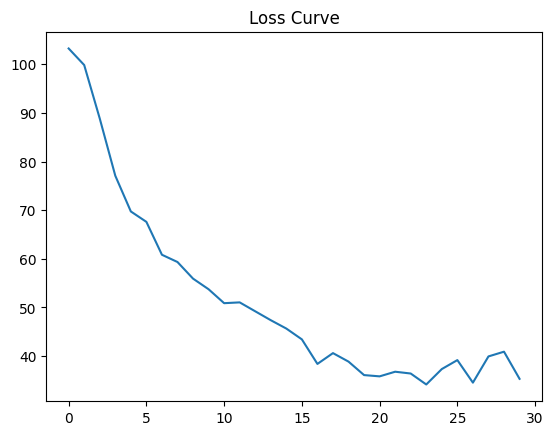

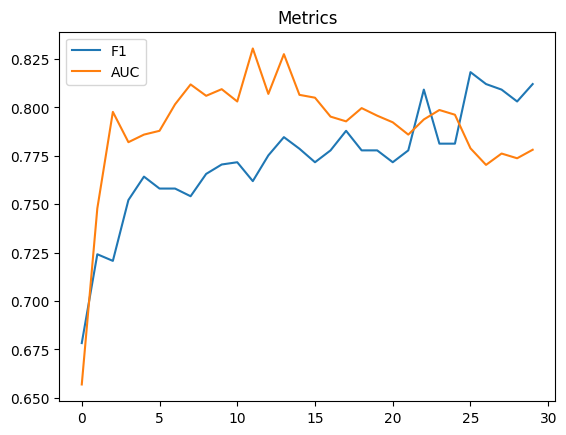

In [ ]:
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.optim import AdamW

from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================
# SEED
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

# ============================================================
# CONFIG
# ============================================================
CFG = {
    "metadata_csv": "/content/drive/MyDrive/preprocessed_data/master_metadata.csv",
    "model_save_dir": "/content/drive/MyDrive/models",
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    "epochs": 30,
    "lr": 5e-5,

    "n_way": 2,
    "k_shot": 2,
    "n_query": 6,
    "episodes": 150,
}

DEVICE = CFG["device"]
os.makedirs(CFG["model_save_dir"], exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(CFG["metadata_csv"])

# Add this renaming step
if "behavioral_path" in df.columns and "behav_path" not in df.columns:
    df = df.rename(columns={"behavioral_path": "behav_path"})

# fix MMSE — fill with group mean if missing (copied from F4HeEZKZQs48)
if df["mmse"].isna().all():
    print("[WARN] All MMSE missing — filling with group means (28=control, 18=dementia)")
    df["mmse"] = df["label"].map({0: 28.0, 1: 18.0})
elif df["mmse"].isna().any():
    print(f"[WARN] {df['mmse'].isna().sum()} MMSE missing — filling with group means")
    df["mmse"] = df["mmse"].fillna(df["label"].map({0: 28.0, 1: 18.0}))

def files_exist(row):
    return (Path(row["audio_path"]).exists() and
            Path(row["text_path"]).exists() and
            Path(row["behav_path"]).exists())

df = df[df.apply(files_exist, axis=1)].reset_index(drop=True)

# ============================================================
# DATASET
# ============================================================
class DatasetFS(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def load(self, p):
        x = np.load(p)
        return np.nan_to_num(x).astype(np.float32)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        audio = self.load(r["audio_path"])
        if audio.ndim == 1:
            audio = audio.reshape(1, -1)

        return {
            "audio": torch.tensor(audio),
            "text": torch.tensor(self.load(r["text_path"])),
            "behav": torch.tensor(self.load(r["behav_path"])),
            "label": torch.tensor(int(r["label"])),
            "mmse": torch.tensor(float(r["mmse"])) # Added mmse
        }

# ============================================================
# BALANCED SAMPLER
# ============================================================
class BalancedSampler:
    def __init__(self, df):
        # Ensure the sampler also works with a 0-based index
        temp_df = df.reset_index(drop=True)
        self.class_idx = defaultdict(list)
        for i, r in temp_df.iterrows(): # 'i' will now be 0, 1, 2...
            self.class_idx[int(r["label"])].append(i)

    def sample_episode(self):
        episode = []
        for cls in self.class_idx:
            pool = self.class_idx[cls]
            k = CFG["k_shot"] + CFG["n_query"]
            # Ensure enough samples are available for the class, handle with choices if not
            if len(pool) < k:
                sampled = random.choices(pool, k=k)
            else:
                sampled = random.sample(pool, k)
            episode += sampled
        return episode

# ============================================================
# MODEL (LIGHT TEMPORAL)
# ============================================================
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        # temporal modeling (LIGHT)
        self.audio_proj = nn.Linear(768, 256)
        self.audio_attn = nn.MultiheadAttention(256, 2, batch_first=True)

        self.text = nn.Linear(768, 256)
        self.behav = nn.Linear(14, 64)

        self.fusion = nn.Linear(256+256+64, 256)

    def encode(self, a, t, b):
        a = self.audio_proj(a)
        a, _ = self.audio_attn(a, a, a)
        a = a.mean(1)

        t = self.text(t)
        b = self.behav(b)

        x = torch.cat([a, t, b], dim=-1)
        x = self.fusion(x)

        return F.normalize(x, dim=-1)

# ============================================================
# PROTOTYPE LOGIC
# ============================================================
def compute_prototypes(emb, labels):
    classes = torch.unique(labels)
    # Check for degenerate episodes where only one class might be present in support
    if len(classes) < CFG["n_way"]:
        return None, None # Indicate degenerate episode
    protos = torch.stack([emb[labels==c].mean(0) for c in classes])
    return protos, classes

def classify(qry, protos):
    dists = torch.cdist(qry, protos)
    return -dists # Return negative distances for CrossEntropyLoss

# ============================================================
# HELPER FUNCTION FOR PADDING AUDIO
# ============================================================
def pad_audio(audio_list):
    # Find the maximum sequence length in the batch
    max_seq_len = max(a.shape[0] for a in audio_list)
    # Assuming feature dimension is 768
    feature_dim = audio_list[0].shape[1]

    padded_audio_tensors = []
    for audio_tensor in audio_list:
        current_seq_len = audio_tensor.shape[0]
        # Calculate padding needed
        padding_needed = max_seq_len - current_seq_len
        # Pad with zeros at the end
        padded_tensor = F.pad(audio_tensor, (0, 0, 0, padding_needed), 'constant', 0)
        padded_audio_tensors.append(padded_tensor)

    return torch.stack(padded_audio_tensors)

# ============================================================
# EPISODIC COLLATOR
# ============================================================
def collate_episode_fs(batch_samples, n_way, k_shot, n_query):
    # batch_samples are ordered by class, e.g., [cls0_k+q, cls1_k+q, ...]
    per_class_samples = k_shot + n_query

    sup_audio, sup_text, sup_behav, sup_labels = [], [], [], []
    qry_audio, qry_text, qry_behav, qry_labels, qry_mmse = [], [], [], [], []

    for c_idx in range(n_way):
        class_batch = batch_samples[c_idx * per_class_samples : (c_idx + 1) * per_class_samples]

        # Support samples for this class
        for s in class_batch[:k_shot]:
            sup_audio.append(s["audio"])
            sup_text.append(s["text"])
            sup_behav.append(s["behav"])
            sup_labels.append(s["label"])

        # Query samples for this class
        for s in class_batch[k_shot:]:
            qry_audio.append(s["audio"])
            qry_text.append(s["text"])
            qry_behav.append(s["behav"])
            qry_labels.append(s["label"])
            qry_mmse.append(s["mmse"])

    return {
        "sup_audio": pad_audio(sup_audio),
        "sup_text": torch.stack(sup_text),
        "sup_behav": torch.stack(sup_behav),
        "sup_labels": torch.stack(sup_labels),
        "qry_audio": pad_audio(qry_audio),
        "qry_text": torch.stack(qry_text),
        "qry_behav": torch.stack(qry_behav),
        "qry_labels": torch.stack(qry_labels),
        "qry_mmse": torch.stack(qry_mmse),
    }

# ============================================================
# TRAIN
# ============================================================
def train(df):

    train_df, val_df = train_test_split(df, test_size=0.2,
                                        stratify=df["label"], random_state=42)

    train_ds = DatasetFS(train_df)
    val_ds   = DatasetFS(val_df)

    sampler = BalancedSampler(train_df)

    model = Model().to(DEVICE)
    opt = AdamW(model.parameters(), lr=CFG["lr"])

    history = {"train_loss":[], "val_f1":[], "val_auc":[]}

    for ep in range(CFG["epochs"]):

        model.train()
        total_loss = 0

        for _ in range(CFG["episodes"]):
            idx = sampler.sample_episode()
            batch = [train_ds[i] for i in idx]

            episode_data = collate_episode_fs(
                batch, CFG["n_way"], CFG["k_shot"], CFG["n_query"]
            )

            sup_emb = model.encode(
                episode_data["sup_audio"].to(DEVICE),
                episode_data["sup_text"].to(DEVICE),
                episode_data["sup_behav"].to(DEVICE),
            )
            qry_emb = model.encode(
                episode_data["qry_audio"].to(DEVICE),
                episode_data["qry_text"].to(DEVICE),
                episode_data["qry_behav"].to(DEVICE),
            )

            sup_y = episode_data["sup_labels"].to(DEVICE)
            qry_y = episode_data["qry_labels"].to(DEVICE)

            protos, classes = compute_prototypes(sup_emb, sup_y)

            # Handle degenerate episodes
            if protos is None:
                # print("Skipping degenerate episode: support set does not contain all classes.")
                continue

            dists_for_loss = classify(qry_emb, protos)

            label_map = {c.item():i for i,c in enumerate(classes)}
            targets = torch.tensor([label_map[l.item()] for l in qry_y]).to(DEVICE)

            loss = F.cross_entropy(dists_for_loss, targets)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()

        # ================= VALIDATION =================
        model.eval()
        embs, labels = [], []

        with torch.no_grad():
            for i in range(len(val_ds)):
                s = val_ds[i]
                # For validation, encode single samples. No need for padding here.
                e = model.encode(
                    s["audio"].unsqueeze(0).to(DEVICE),
                    s["text"].unsqueeze(0).to(DEVICE),
                    s["behav"].unsqueeze(0).to(DEVICE)
                )
                embs.append(e.squeeze(0))
                labels.append(s["label"].item())

        embs = torch.stack(embs)
        labels = torch.tensor(labels).to(DEVICE)

        protos, classes = compute_prototypes(embs, labels)

        # Handle degenerate validation set (if it happens, though less likely with train_test_split stratify)
        if protos is None:
            print("Skipping validation metrics for epoch due to degenerate validation set.")
            f1, auc = 0.0, 0.0 # Assign default values or skip logging
        else:
            dists_for_probs = classify(embs, protos) # Get negative distances
            probs = torch.softmax(dists_for_probs, dim=1)

            preds = probs.argmax(1).cpu().numpy()

            # Ensure class 1 probability is taken if it exists, otherwise default to 0
            # This requires knowing which index corresponds to class 1 in 'classes'
            if 1 in classes:
                class_1_idx = classes.tolist().index(1)
                probs_cls1 = probs[:, class_1_idx].cpu().numpy()
            else:
                probs_cls1 = np.zeros(len(labels)) # No class 1 in validation protos, so assign 0 prob

            labels_np = labels.cpu().numpy()

            f1 = f1_score(labels_np, preds, zero_division=0)
            try:
                auc = roc_auc_score(labels_np, probs_cls1)
            except ValueError: # Handle cases where only one class is present in labels_np, preventing AUC calculation
                auc = 0.0

        history["train_loss"].append(total_loss)
        history["val_f1"].append(f1)
        history["val_auc"].append(auc)

        print(f"Epoch {ep+1} | Loss {total_loss:.2f} | F1 {f1:.3f} | AUC {auc:.3f}")

    # ============================================================
    # PLOTS
    # ============================================================
    plt.figure()
    plt.plot(history["train_loss"])
    plt.title("Loss Curve")
    plt.savefig(f"{CFG['model_save_dir']}/loss.png")

    plt.figure()
    plt.plot(history["val_f1"], label="F1")
    plt.plot(history["val_auc"], label="AUC")
    plt.legend()
    plt.title("Metrics")
    plt.savefig(f"{CFG['model_save_dir']}/metrics.png")

    print("Plots saved.")

# ============================================================
# RUN
# ============================================================
train(df[df["task"]=="cookie"])

## imp 2

In [ ]:
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW

from sklearn.metrics import (
    f1_score, roc_auc_score,
    accuracy_score, precision_score, recall_score
)
from sklearn.model_selection import train_test_split

# ============================================================
# SEED
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

# ============================================================
# CONFIG
# ============================================================
CFG = {
    "metadata_csv": "/content/drive/MyDrive/preprocessed_data/master_metadata.csv",
    "model_save_dir": "/content/drive/MyDrive/models",
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    "epochs": 30,
    "lr": 5e-5,
    "weight_decay": 1e-4,

    "patience": 5,
    "contrastive_weight": 0.3,
    "temperature": 0.1
}

DEVICE = CFG["device"]
os.makedirs(CFG["model_save_dir"], exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(CFG["metadata_csv"])

if "behavioral_path" in df.columns and "behav_path" not in df.columns:
    df = df.rename(columns={"behavioral_path": "behav_path"})

# Task encoding
task2id = {t:i for i,t in enumerate(df["task"].unique())}
df["task_id"] = df["task"].map(task2id)

def files_exist(row):
    return (Path(row["audio_path"]).exists() and
            Path(row["text_path"]).exists() and
            Path(row["behav_path"]).exists())

df = df[df.apply(files_exist, axis=1)].reset_index(drop=True)

# ============================================================
# DATASET
# ============================================================
class DatasetFS:
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def load(self, p):
        x = np.load(p)
        x = np.nan_to_num(x).astype(np.float32)

        # Noise augmentation
        if random.random() < 0.3:
            x += np.random.normal(0, 0.01, x.shape)

        return x

    def __getitem__(self, i):
        r = self.df.iloc[i]

        audio = self.load(r["audio_path"])
        if audio.ndim == 1:
            audio = audio.reshape(1, -1)

        return {
            "audio": torch.tensor(audio),
            "text": torch.tensor(self.load(r["text_path"])),
            "behav": torch.tensor(self.load(r["behav_path"])),
            "label": int(r["label"]),
            "task_id": int(r["task_id"])
        }

    def __len__(self):
        return len(self.df)

# ============================================================
# MODEL COMPONENTS
# ============================================================
class ConformerBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.ff = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim*4),
            nn.GELU(),
            nn.Linear(dim*4, dim)
        )

        self.attn = nn.MultiheadAttention(dim, 4, batch_first=True)

        self.conv = nn.Sequential(
            nn.Conv1d(dim, dim, 3, padding=1, groups=dim),
            nn.GELU(),
            nn.Conv1d(dim, dim, 1)
        )

        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        x = x + self.ff(x)

        attn, _ = self.attn(x, x, x)
        x = x + attn

        conv = self.conv(x.transpose(1,2)).transpose(1,2)
        x = x + conv

        return self.norm(x)

class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return (x * w).sum(dim=1)

# ============================================================
# MODEL
# ============================================================
class Model(nn.Module):
    def __init__(self, num_tasks):
        super().__init__()

        self.audio_proj = nn.Linear(768, 256)
        self.conf = ConformerBlock(256)
        self.pool = AttentionPooling(256)

        self.text = nn.Linear(768, 256)
        self.behav = nn.Linear(14, 64)

        self.task_emb = nn.Embedding(num_tasks, 32)

        self.fusion = nn.Sequential(
            nn.Linear(256+256+64+32, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # FIXED CLASSIFIER
        self.classifier = nn.Linear(256, 1)

    def encode(self, a, t, b, task_id):
        a = self.audio_proj(a)
        a = self.conf(a)
        a = self.pool(a)

        t = self.text(t)
        b = self.behav(b)
        task = self.task_emb(task_id)

        x = torch.cat([a, t, b, task], dim=-1)
        x = self.fusion(x)

        return F.normalize(x, dim=-1)

    def forward(self, a, t, b, task_id):
        emb = self.encode(a, t, b, task_id)
        logit = self.classifier(emb)
        return emb, logit

# ============================================================
# CONTRASTIVE LOSS
# ============================================================
def contrastive_loss(emb, labels):
    emb = F.normalize(emb, dim=1)
    sim = torch.matmul(emb, emb.T) / CFG["temperature"]

    labels = labels.unsqueeze(1)
    mask = (labels == labels.T).float()

    exp_sim = torch.exp(sim) * (1 - torch.eye(len(emb), device=emb.device))
    log_prob = sim - torch.log(exp_sim.sum(dim=1, keepdim=True))

    loss = -(mask * log_prob).sum(1) / mask.sum(1)
    return loss.mean()

# ============================================================
# TRAIN
# ============================================================
def train(df):

    train_df, val_df = train_test_split(
        df, test_size=0.2, stratify=df["label"], random_state=42
    )

    train_ds = DatasetFS(train_df)
    val_ds   = DatasetFS(val_df)

    model = Model(num_tasks=len(task2id)).to(DEVICE)

    opt = AdamW(model.parameters(),
                lr=CFG["lr"],
                weight_decay=CFG["weight_decay"])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='max', patience=2
    )

    best_f1 = 0
    counter = 0

    for ep in range(CFG["epochs"]):

        model.train()
        total_loss = 0

        for i in range(len(train_ds)):

            s = train_ds[i]

            audio = s["audio"].unsqueeze(0).to(DEVICE)
            text  = s["text"].unsqueeze(0).to(DEVICE)
            behav = s["behav"].unsqueeze(0).to(DEVICE)
            label = torch.tensor([s["label"]]).float().to(DEVICE)
            task  = torch.tensor([s["task_id"]]).to(DEVICE)

            emb, logit = model(audio, text, behav, task)

            ce_loss = F.binary_cross_entropy_with_logits(
                logit.view(-1), label
            )

            cont_loss = contrastive_loss(emb, label.long())

            loss = ce_loss + CFG["contrastive_weight"] * cont_loss

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            total_loss += loss.item()

        # ================= VALIDATION =================
        model.eval()
        preds, probs, labels_all = [], [], []

        with torch.no_grad():
            for i in range(len(val_ds)):
                s = val_ds[i]

                audio = s["audio"].unsqueeze(0).to(DEVICE)
                text  = s["text"].unsqueeze(0).to(DEVICE)
                behav = s["behav"].unsqueeze(0).to(DEVICE)
                task  = torch.tensor([s["task_id"]]).to(DEVICE)

                _, logit = model(audio, text, behav, task)

                prob = torch.sigmoid(logit).item()

                preds.append(int(prob > 0.5))
                probs.append(prob)
                labels_all.append(s["label"])

        f1 = f1_score(labels_all, preds, zero_division=0)
        acc = accuracy_score(labels_all, preds)
        prec = precision_score(labels_all, preds, zero_division=0)
        rec = recall_score(labels_all, preds, zero_division=0)

        try:
            auc = roc_auc_score(labels_all, probs)
        except:
            auc = 0

        print(f"\nEpoch {ep+1}")
        print(f"Loss: {total_loss:.2f}")
        print(f"F1: {f1:.3f} | Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | AUC: {auc:.3f}")

        scheduler.step(f1)

        if f1 > best_f1:
            best_f1 = f1
            counter = 0
            torch.save(model.state_dict(),
                       f"{CFG['model_save_dir']}/best_model.pt")
        else:
            counter += 1

        if counter >= CFG["patience"]:
            print("Early stopping triggered")
            break

    print("Training complete. Best F1:", best_f1)

# ============================================================
# RUN
# ============================================================
train(df)


Epoch 1
Loss: nan
F1: 0.000 | Acc: 0.179 | Prec: 0.000 | Rec: 0.000 | AUC: 0.000

Epoch 2
Loss: nan
F1: 0.000 | Acc: 0.179 | Prec: 0.000 | Rec: 0.000 | AUC: 0.000

Epoch 3
Loss: nan
F1: 0.000 | Acc: 0.179 | Prec: 0.000 | Rec: 0.000 | AUC: 0.000

Epoch 4
Loss: nan
F1: 0.000 | Acc: 0.179 | Prec: 0.000 | Rec: 0.000 | AUC: 0.000

Epoch 5
Loss: nan
F1: 0.000 | Acc: 0.179 | Prec: 0.000 | Rec: 0.000 | AUC: 0.000
Early stopping triggered
Training complete. Best F1: 0


# Take 2


## features

In [ ]:
from pathlib import Path
import torch
import torchaudio
import numpy as np
import pandas as pd
import re
from tqdm import tqdm
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from sentence_transformers import SentenceTransformer

# ================= CONFIG =================
ROOT = Path("/content/drive/MyDrive/preprocessed_data/control/sentence")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SR = 16000

# AUDIO
CHUNK_SEC = 10
OVERLAP_SEC = 2

print("Device:", DEVICE)

# ================= LOAD MODELS =================
# wav2vec
wav_processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
wav_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h").to(DEVICE)
wav_model.eval()

# BETTER TEXT MODEL (replaces ClinicalBERT)
text_model = SentenceTransformer("all-MiniLM-L6-v2", device=DEVICE)

# ================= AUDIO FEATURE =================
def extract_audio_embedding(wav_path):
    waveform, sr = torchaudio.load(wav_path)

    if sr != SR:
        waveform = torchaudio.transforms.Resample(sr, SR)(waveform)

    waveform = waveform.mean(dim=0)
    waveform = waveform / (waveform.abs().max() + 1e-9)

    chunk_size = CHUNK_SEC * SR
    overlap = OVERLAP_SEC * SR
    step = chunk_size - overlap

    total = waveform.shape[0]
    chunk_feats = []

    start = 0
    while start < total:
        end = min(start + chunk_size, total)
        chunk = waveform[start:end]

        if len(chunk) < SR * 1:
            break

        inputs = wav_processor(
            chunk.numpy(),
            sampling_rate=SR,
            return_tensors="pt",
            padding=True
        )
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        with torch.no_grad():
            out = wav_model(**inputs)

        feat = out.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
        chunk_feats.append(feat)

        start += step

    if not chunk_feats:
        return None, None

    chunk_feats = np.array(chunk_feats)  # (num_chunks, 768)

    # ✅ CRITICAL: patient-level embedding
    patient_emb = chunk_feats.mean(axis=0)

    return chunk_feats, patient_emb


# ================= BEHAVIORAL FEATURES =================
def extract_behavioral(df):
    df = df.sort_values("start").reset_index(drop=True)

    durations = df["end"] - df["start"]

    # pauses (>300ms)
    gaps = []
    for i in range(1, len(df)):
        gap = df.loc[i, "start"] - df.loc[i-1, "end"]
        if gap > 0.3:
            gaps.append(gap)

    total_words = df["text"].fillna("").apply(lambda x: len(x.split())).sum()
    total_speech = durations.sum()

    speech_rate = total_words / total_speech if total_speech > 0 else 0

    feats = [
        len(gaps),
        np.mean(gaps) if gaps else 0,
        np.max(gaps) if gaps else 0,
        speech_rate,
        len(df),
        durations.mean(),
        durations.std() if len(df) > 1 else 0,
        durations.max()
    ]

    return np.array(feats, dtype=np.float32)


# ================= TEXT EMBEDDING =================
def extract_text_embedding(df):
    full_text = " ".join(df["text"].fillna("").tolist())

    if len(full_text.strip()) == 0:
        return np.zeros(384)

    emb = text_model.encode(full_text)
    return np.array(emb, dtype=np.float32)


# ================= FIND WAV =================
def find_wav(session):
    p = session / "patient_only.wav"
    if p.exists():
        return p

    wavs = list(session.glob("*.wav"))
    return wavs[0] if wavs else None


# ================= MAIN LOOP =================
processed, skipped, failed = 0, 0, []

for session in tqdm(sorted(ROOT.iterdir())):
    if not session.is_dir():
        continue

    out_audio = session / "audio_embedding.npy"
    out_text  = session / "text_embedding.npy"
    out_behav = session / "behavioral_features.npy"
    out_final = session / "final_fused.npy"

    if out_final.exists():
        skipped += 1
        continue

    try:
        # ---------- AUDIO ----------
        wav_path = find_wav(session)
        if wav_path is None:
            print(f"[MISS] No audio: {session.name}")
            continue

        chunk_feats, audio_emb = extract_audio_embedding(wav_path)
        if audio_emb is None:
            print(f"[WARN] Empty audio: {session.name}")
            continue

        # ---------- TEXT + BEHAVIOR ----------
        turn_csv = session / "turn.csv"
        if not turn_csv.exists():
            print(f"[MISS] No turn.csv: {session.name}")
            continue

        df = pd.read_csv(turn_csv)

        behav = extract_behavioral(df)
        text  = extract_text_embedding(df)

        # ---------- SAVE ----------
        np.save(out_audio, audio_emb)
        np.save(out_text, text)
        np.save(out_behav, behav)

        # ---------- FINAL FUSION ----------
        final_vec = np.concatenate([audio_emb, text, behav])

        np.save(out_final, final_vec)

        processed += 1
        print(f"[OK] {session.name} | final: {final_vec.shape}")

    except Exception as e:
        failed.append(session.name)
        print(f"[FAIL] {session.name} — {e}")

print(f"\nDone: {processed} | Skipped: {skipped} | Failed: {len(failed)}")
if failed:
    print("Failed:", failed)

Device: cpu


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 1/1 [00:20<00:00, 20.99s/it]

[OK] 332-0 | final: (1160,)

Done: 1 | Skipped: 0 | Failed: 0


Device: cpu
Loaded: (946, 1160)

Epoch 1
Train Loss: 0.5362
Train Acc : 0.7325
Val Acc   : 0.6625

Epoch 2
Train Loss: 0.3997
Train Acc : 0.8375
Val Acc   : 0.7562

Epoch 3
Train Loss: 0.3970
Train Acc : 0.8575
Val Acc   : 0.7625

Epoch 4
Train Loss: 0.3921
Train Acc : 0.8575
Val Acc   : 0.7375

Epoch 5
Train Loss: 0.3643
Train Acc : 0.8475
Val Acc   : 0.8500

Epoch 6
Train Loss: 0.3276
Train Acc : 0.8950
Val Acc   : 0.8438

Epoch 7
Train Loss: 0.2617
Train Acc : 0.9300
Val Acc   : 0.7250

Epoch 8
Train Loss: 0.2714
Train Acc : 0.9200
Val Acc   : 0.8313

Epoch 9
Train Loss: 0.2613
Train Acc : 0.9250
Val Acc   : 0.8000

Epoch 10
Train Loss: 0.1977
Train Acc : 0.9475
Val Acc   : 0.7562

Epoch 11
Train Loss: 0.2413
Train Acc : 0.9250
Val Acc   : 0.6750

Epoch 12
Train Loss: 0.2340
Train Acc : 0.9475
Val Acc   : 0.7000

Epoch 13
Train Loss: 0.2274
Train Acc : 0.9375
Val Acc   : 0.7312
Early stopping triggered

Classification Report:
              precision    recall  f1-score   support

  

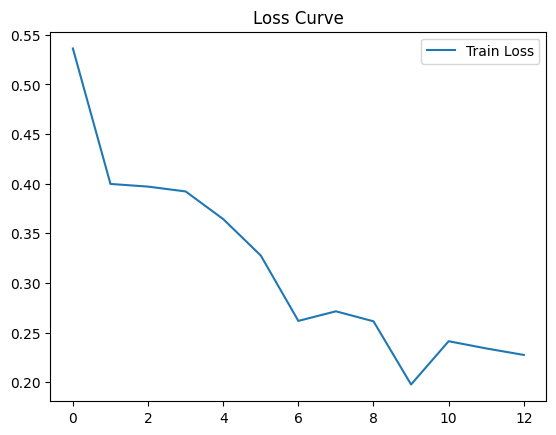

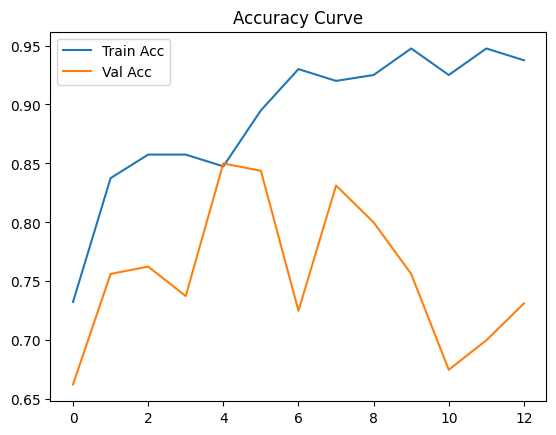

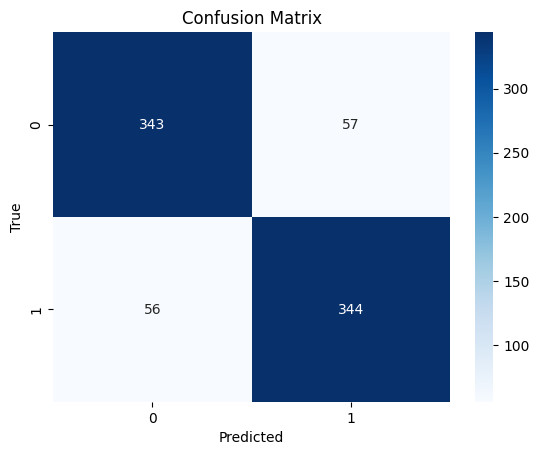

In [ ]:
# ============================================================
# 🔥 FULL PIPELINE: FEW-SHOT PROTOTYPICAL TRAINING
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import random
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ================= CONFIG =================
ROOT = Path("/content/drive/MyDrive/preprocessed_data")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 👉 USE 2-CLASS (recommended)
LABEL_MAP = {
    "control": 0,
    "dementia": 1
}

TASKS = ["cookie", "fluency", "sentence"]

# Few-shot config
N_WAY = 2
K_SHOT = 2
Q_QUERY = 4

EPOCHS = 50
EPISODES_PER_EPOCH = 50
PATIENCE = 8

print("Device:", DEVICE)

# ================= LOAD DATA =================
def load_data():
    X, y = [], []

    for group in LABEL_MAP.keys():
        for task in TASKS:
            folder = ROOT / group / task
            if not folder.exists():
                continue

            for session in folder.iterdir():
                f = session / "final_fused.npy"
                if f.exists():
                    X.append(np.load(f))
                    y.append(LABEL_MAP[group])

    return np.array(X), np.array(y)

X, y = load_data()
print("Loaded:", X.shape)

# ================= NORMALIZE =================
scaler = StandardScaler()
X = scaler.fit_transform(X)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

# ================= SPLIT =================
def train_val_split(X, y, val_ratio=0.2):
    idx = torch.randperm(len(X))
    split = int(len(X) * (1 - val_ratio))
    return X[idx[:split]], y[idx[:split]], X[idx[split:]], y[idx[split:]]

X_train, y_train, X_val, y_val = train_val_split(X, y)

# ================= MODEL =================
class EmbeddingNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 256)
        )

    def forward(self, x):
        x = self.net(x)
        return F.normalize(x, dim=1)  # 🔥 critical

model = EmbeddingNet(X.shape[1]).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# ================= SAMPLER =================
def sample_episode(X, y, n_way=N_WAY, k_shot=K_SHOT, q_query=Q_QUERY):
    classes = torch.unique(y)
    selected = classes[torch.randperm(len(classes))[:n_way]]

    support_x, support_y = [], []
    query_x, query_y = [], []

    for i, cls in enumerate(selected):
        idx = (y == cls).nonzero().squeeze()
        idx = idx[torch.randperm(len(idx))]

        k = min(k_shot, len(idx) - 1)
        q = min(q_query, len(idx) - k)

        support_idx = idx[:k]
        query_idx   = idx[k:k+q]

        support_x.append(X[support_idx])
        support_y.append(torch.full((k,), i))

        query_x.append(X[query_idx])
        query_y.append(torch.full((q,), i))

    return (
        torch.cat(support_x),
        torch.cat(support_y),
        torch.cat(query_x),
        torch.cat(query_y)
    )

# ================= PROTOTYPE =================
def compute_prototypes(emb, labels, n_way):
    return torch.stack([
        emb[labels == i].mean(0) for i in range(n_way)
    ])

def proto_loss(query_emb, prototypes, query_labels, temperature=0.7):
    sim = F.cosine_similarity(
        query_emb.unsqueeze(1),
        prototypes.unsqueeze(0),
        dim=2
    )

    logits = sim / temperature
    loss = F.cross_entropy(logits, query_labels)

    preds = logits.argmax(dim=1)
    acc = (preds == query_labels).float().mean()

    return loss, acc

# ================= TRAIN =================
train_losses, train_accs, val_accs = [], [], []

best_val = 0
counter = 0

for epoch in range(EPOCHS):
    model.train()
    total_loss, total_acc = 0, 0

    for _ in range(EPISODES_PER_EPOCH):
        sx, sy, qx, qy = sample_episode(X_train, y_train)

        sx, sy = sx.to(DEVICE), sy.to(DEVICE)
        qx, qy = qx.to(DEVICE), qy.to(DEVICE)

        emb_s = model(sx)
        emb_q = model(qx)

        prototypes = compute_prototypes(emb_s, sy, N_WAY)

        loss, acc = proto_loss(emb_q, prototypes, qy)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_acc  += acc.item()

    avg_loss = total_loss / EPISODES_PER_EPOCH
    avg_acc  = total_acc  / EPISODES_PER_EPOCH

    # ---------- VALIDATION ----------
    model.eval()
    val_scores = []

    with torch.no_grad():
        for _ in range(20):
            sx, sy, qx, qy = sample_episode(X_val, y_val)

            sx, sy = sx.to(DEVICE), sy.to(DEVICE)
            qx, qy = qx.to(DEVICE), qy.to(DEVICE)

            emb_s = model(sx)
            emb_q = model(qx)

            prototypes = compute_prototypes(emb_s, sy, N_WAY)

            sim = F.cosine_similarity(
                emb_q.unsqueeze(1),
                prototypes.unsqueeze(0),
                dim=2
            )

            preds = sim.argmax(dim=1)
            acc = (preds == qy).float().mean().item()

            val_scores.append(acc)

    val_acc = np.mean(val_scores)

    train_losses.append(avg_loss)
    train_accs.append(avg_acc)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {avg_loss:.4f}")
    print(f"Train Acc : {avg_acc:.4f}")
    print(f"Val Acc   : {val_acc:.4f}")

    # ---------- EARLY STOP ----------
    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= PATIENCE:
            print("Early stopping triggered")
            break

# ================= FINAL EVAL =================
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds, all_true = [], []

with torch.no_grad():
    for _ in range(100):
        sx, sy, qx, qy = sample_episode(X_val, y_val)

        sx, sy = sx.to(DEVICE), sy.to(DEVICE)
        qx, qy = qx.to(DEVICE), qy.to(DEVICE)

        emb_s = model(sx)
        emb_q = model(qx)

        prototypes = compute_prototypes(emb_s, sy, N_WAY)

        sim = F.cosine_similarity(
            emb_q.unsqueeze(1),
            prototypes.unsqueeze(0),
            dim=2
        )

        preds = sim.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(qy.cpu().numpy())

print("\nClassification Report:")
print(classification_report(all_true, all_preds))

cm = confusion_matrix(all_true, all_preds)

# ================= PLOTS =================

# Loss
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

# Accuracy
plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

# Confusion Matrix
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

#  Final model

Device: cpu
Loaded: (946, 1160)

🔥 Fold 1
Epoch 1 | Loss: 0.4979 | Train Acc: 0.7750 | Val Acc: 0.9000
Epoch 2 | Loss: 0.3611 | Train Acc: 0.8425 | Val Acc: 0.8900
Epoch 3 | Loss: 0.3059 | Train Acc: 0.8975 | Val Acc: 0.8700
Epoch 4 | Loss: 0.2711 | Train Acc: 0.9075 | Val Acc: 0.8750
Epoch 5 | Loss: 0.2349 | Train Acc: 0.9250 | Val Acc: 0.9200
Epoch 6 | Loss: 0.3336 | Train Acc: 0.8775 | Val Acc: 0.8200
Epoch 7 | Loss: 0.2583 | Train Acc: 0.9075 | Val Acc: 0.8600
Epoch 8 | Loss: 0.1831 | Train Acc: 0.9400 | Val Acc: 0.8250
Epoch 9 | Loss: 0.1879 | Train Acc: 0.9250 | Val Acc: 0.7850
Epoch 10 | Loss: 0.1989 | Train Acc: 0.9450 | Val Acc: 0.8300
Epoch 11 | Loss: 0.1362 | Train Acc: 0.9575 | Val Acc: 0.8000
Epoch 12 | Loss: 0.0911 | Train Acc: 0.9750 | Val Acc: 0.8200
Epoch 13 | Loss: 0.1075 | Train Acc: 0.9725 | Val Acc: 0.8050
Early stopping

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       500
           1 

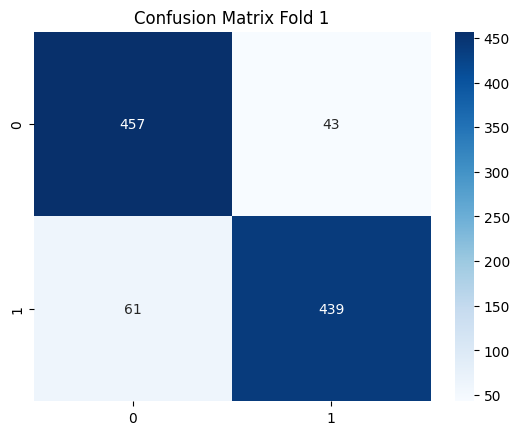


🔥 Fold 2
Epoch 1 | Loss: 0.4987 | Train Acc: 0.7975 | Val Acc: 0.7950
Epoch 2 | Loss: 0.3656 | Train Acc: 0.8600 | Val Acc: 0.7500
Epoch 3 | Loss: 0.2843 | Train Acc: 0.9025 | Val Acc: 0.8050
Epoch 4 | Loss: 0.2703 | Train Acc: 0.9150 | Val Acc: 0.7400
Epoch 5 | Loss: 0.2128 | Train Acc: 0.9225 | Val Acc: 0.7500
Epoch 6 | Loss: 0.1910 | Train Acc: 0.9450 | Val Acc: 0.7850
Epoch 7 | Loss: 0.1340 | Train Acc: 0.9600 | Val Acc: 0.7400
Epoch 8 | Loss: 0.1482 | Train Acc: 0.9575 | Val Acc: 0.7850
Epoch 9 | Loss: 0.1569 | Train Acc: 0.9450 | Val Acc: 0.7250
Epoch 10 | Loss: 0.0925 | Train Acc: 0.9750 | Val Acc: 0.7600
Epoch 11 | Loss: 0.2347 | Train Acc: 0.9225 | Val Acc: 0.8700
Epoch 12 | Loss: 0.1215 | Train Acc: 0.9675 | Val Acc: 0.7400
Epoch 13 | Loss: 0.0778 | Train Acc: 0.9800 | Val Acc: 0.7100
Epoch 14 | Loss: 0.0858 | Train Acc: 0.9750 | Val Acc: 0.7100
Epoch 15 | Loss: 0.1023 | Train Acc: 0.9750 | Val Acc: 0.8000
Epoch 16 | Loss: 0.1371 | Train Acc: 0.9625 | Val Acc: 0.8400
Epoch 1

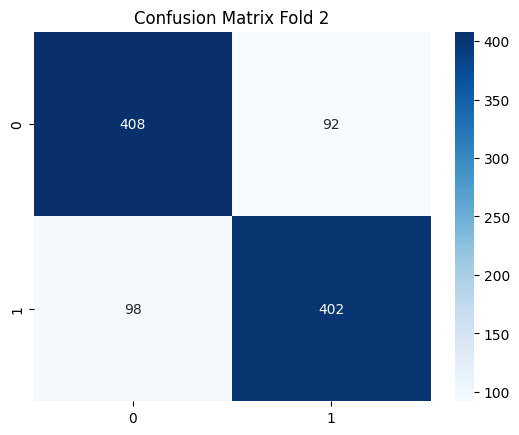


🔥 Fold 3
Epoch 1 | Loss: 0.4955 | Train Acc: 0.8125 | Val Acc: 0.8200
Epoch 2 | Loss: 0.4444 | Train Acc: 0.8175 | Val Acc: 0.7950
Epoch 3 | Loss: 0.2950 | Train Acc: 0.8925 | Val Acc: 0.8400
Epoch 4 | Loss: 0.2383 | Train Acc: 0.9125 | Val Acc: 0.7650
Epoch 5 | Loss: 0.2063 | Train Acc: 0.9300 | Val Acc: 0.8250
Epoch 6 | Loss: 0.2359 | Train Acc: 0.9200 | Val Acc: 0.7500
Epoch 7 | Loss: 0.2464 | Train Acc: 0.9150 | Val Acc: 0.8000
Epoch 8 | Loss: 0.1496 | Train Acc: 0.9650 | Val Acc: 0.7900
Epoch 9 | Loss: 0.1708 | Train Acc: 0.9425 | Val Acc: 0.7650
Epoch 10 | Loss: 0.2038 | Train Acc: 0.9250 | Val Acc: 0.8250
Epoch 11 | Loss: 0.1241 | Train Acc: 0.9700 | Val Acc: 0.7700
Early stopping

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.82       500
           1       0.83      0.81      0.82       500

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weight

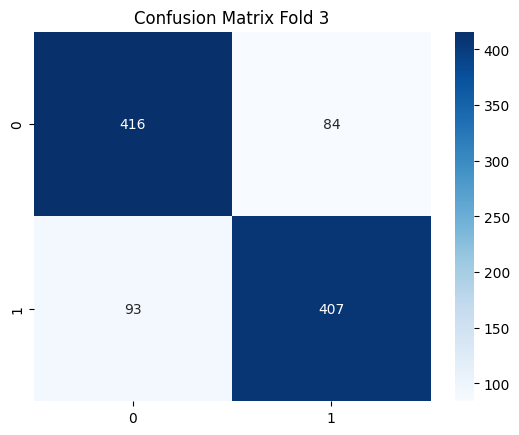


🔥 Fold 4
Epoch 1 | Loss: 0.4950 | Train Acc: 0.7575 | Val Acc: 0.8150
Epoch 2 | Loss: 0.3634 | Train Acc: 0.8325 | Val Acc: 0.7350
Epoch 3 | Loss: 0.3022 | Train Acc: 0.8900 | Val Acc: 0.7100
Epoch 4 | Loss: 0.2986 | Train Acc: 0.9050 | Val Acc: 0.8050
Epoch 5 | Loss: 0.2900 | Train Acc: 0.8950 | Val Acc: 0.7600
Epoch 6 | Loss: 0.2243 | Train Acc: 0.9200 | Val Acc: 0.7250
Epoch 7 | Loss: 0.2347 | Train Acc: 0.9250 | Val Acc: 0.8450
Epoch 8 | Loss: 0.1821 | Train Acc: 0.9450 | Val Acc: 0.8350
Epoch 9 | Loss: 0.1108 | Train Acc: 0.9600 | Val Acc: 0.8400
Epoch 10 | Loss: 0.2042 | Train Acc: 0.9425 | Val Acc: 0.7650
Epoch 11 | Loss: 0.1692 | Train Acc: 0.9525 | Val Acc: 0.7500
Epoch 12 | Loss: 0.1340 | Train Acc: 0.9625 | Val Acc: 0.7900
Epoch 13 | Loss: 0.1074 | Train Acc: 0.9725 | Val Acc: 0.7500
Epoch 14 | Loss: 0.1004 | Train Acc: 0.9650 | Val Acc: 0.8300
Epoch 15 | Loss: 0.1172 | Train Acc: 0.9625 | Val Acc: 0.7700
Early stopping

Classification Report:
              precision    rec

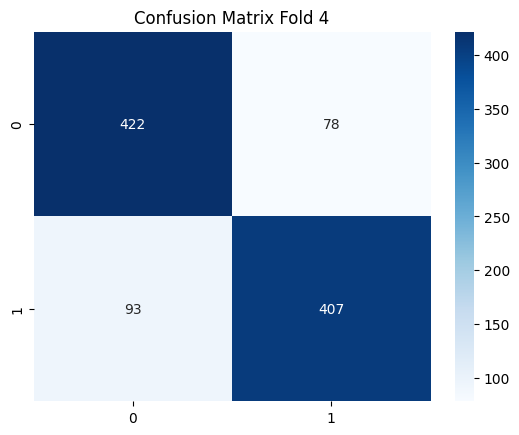


🔥 Fold 5
Epoch 1 | Loss: 0.5305 | Train Acc: 0.7450 | Val Acc: 0.7950
Epoch 2 | Loss: 0.3221 | Train Acc: 0.8825 | Val Acc: 0.8250
Epoch 3 | Loss: 0.4005 | Train Acc: 0.8475 | Val Acc: 0.8750
Epoch 4 | Loss: 0.2248 | Train Acc: 0.9125 | Val Acc: 0.7800
Epoch 5 | Loss: 0.2187 | Train Acc: 0.9200 | Val Acc: 0.8000
Epoch 6 | Loss: 0.2436 | Train Acc: 0.9125 | Val Acc: 0.7350
Epoch 7 | Loss: 0.2106 | Train Acc: 0.9400 | Val Acc: 0.8050
Epoch 8 | Loss: 0.2369 | Train Acc: 0.9350 | Val Acc: 0.7950
Epoch 9 | Loss: 0.1379 | Train Acc: 0.9550 | Val Acc: 0.7600
Epoch 10 | Loss: 0.1661 | Train Acc: 0.9550 | Val Acc: 0.7550
Epoch 11 | Loss: 0.1518 | Train Acc: 0.9525 | Val Acc: 0.8300
Early stopping

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       500
           1       0.85      0.84      0.84       500

    accuracy                           0.84      1000
   macro avg       0.85      0.84      0.84      1000
weight

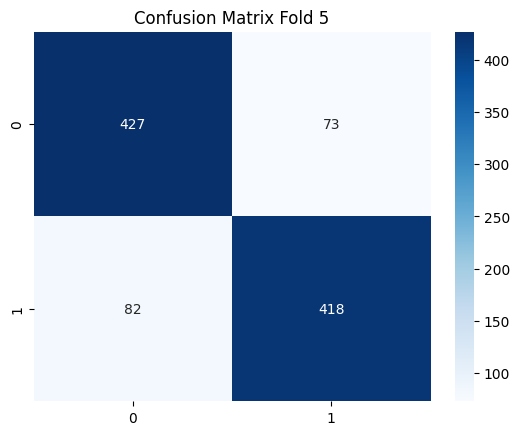


🔥 FINAL RESULTS
Accuracy: 0.8405999999999999
F1 Score: 0.8388655215853824
Precision: 0.8487946441692535
Recall: 0.8291999999999999


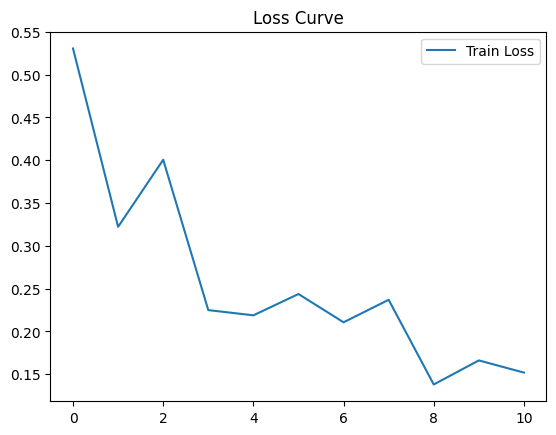

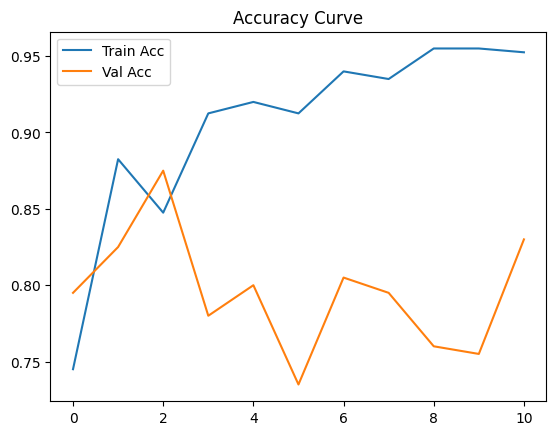

In [ ]:
# ============================================================
# 🔥 FULL PIPELINE (TUNED + CROSS VALIDATION + PLOTS)
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ================= CONFIG =================
ROOT = Path("/content/drive/MyDrive/preprocessed_data")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

LABEL_MAP = {
    "control": 0,
    "dementia": 1
}

TASKS = ["cookie", "fluency", "sentence"]

# 🔥 TUNED PARAMETERS
N_WAY = 2
K_SHOT = 3
Q_QUERY = 5
LR = 5e-4
TEMPERATURE = 0.5
DROPOUT = 0.3
WEIGHT_DECAY = 5e-4

EPOCHS = 50          # ✅ CHANGED
EPISODES_PER_EPOCH = 40
PATIENCE = 8         # ✅ CHANGED

print("Device:", DEVICE)

# ================= LOAD DATA =================
def load_data():
    X, y = [], []

    for group in LABEL_MAP.keys():
        for task in TASKS:
            folder = ROOT / group / task
            if not folder.exists():
                continue

            for session in folder.iterdir():
                f = session / "final_fused.npy"
                if f.exists():
                    X.append(np.load(f))
                    y.append(LABEL_MAP[group])

    return np.array(X), np.array(y)

X, y = load_data()
print("Loaded:", X.shape)

# ================= MODEL =================
class EmbeddingNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(DROPOUT),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 256)
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=1)

# ================= SAMPLER =================
def sample_episode(X, y):
    classes = torch.unique(y)
    selected = classes[torch.randperm(len(classes))[:N_WAY]]

    support_x, support_y = [], []
    query_x, query_y = [], []

    for i, cls in enumerate(selected):
        idx = (y == cls).nonzero().squeeze()
        idx = idx[torch.randperm(len(idx))]

        k = min(K_SHOT, len(idx) - 1)
        q = min(Q_QUERY, len(idx) - k)

        support_idx = idx[:k]
        query_idx   = idx[k:k+q]

        support_x.append(X[support_idx])
        support_y.append(torch.full((k,), i))

        query_x.append(X[query_idx])
        query_y.append(torch.full((q,), i))

    return (
        torch.cat(support_x),
        torch.cat(support_y),
        torch.cat(query_x),
        torch.cat(query_y)
    )

# ================= PROTOTYPE =================
def compute_prototypes(emb, labels):
    return torch.stack([
        emb[labels == i].mean(0) for i in range(N_WAY)
    ])

def proto_loss(query_emb, prototypes, query_labels):
    sim = F.cosine_similarity(
        query_emb.unsqueeze(1),
        prototypes.unsqueeze(0),
        dim=2
    )
    logits = sim / TEMPERATURE
    loss = F.cross_entropy(logits, query_labels)
    preds = logits.argmax(dim=1)
    acc = (preds == query_labels).float().mean()
    return loss, acc

# ================= CROSS VALIDATION =================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_fold_acc = []
all_fold_f1  = []
all_fold_precision = []   # ✅ NEW
all_fold_recall = []      # ✅ NEW

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\n🔥 Fold {fold+1}")

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val     = X[val_idx], y[val_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)

    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    X_val   = torch.tensor(X_val, dtype=torch.float32)
    y_val   = torch.tensor(y_val, dtype=torch.long)

    model = EmbeddingNet(X_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_val = 0
    patience_counter = 0

    train_losses, val_accs, train_accs = [], [], []   # ✅ FIXED

    # ================= TRAIN =================
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        total_acc = 0

        for _ in range(EPISODES_PER_EPOCH):
            sx, sy, qx, qy = sample_episode(X_train, y_train)

            sx, sy = sx.to(DEVICE), sy.to(DEVICE)
            qx, qy = qx.to(DEVICE), qy.to(DEVICE)

            emb_s = model(sx)
            emb_q = model(qx)

            prototypes = compute_prototypes(emb_s, sy)

            loss, acc = proto_loss(emb_q, prototypes, qy)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            total_acc += acc.item()

        avg_loss = total_loss / EPISODES_PER_EPOCH
        avg_acc  = total_acc / EPISODES_PER_EPOCH

        train_losses.append(avg_loss)
        train_accs.append(avg_acc)

        # -------- VALIDATION --------
        model.eval()
        val_scores = []

        with torch.no_grad():
            for _ in range(20):
                sx, sy, qx, qy = sample_episode(X_val, y_val)

                sx, sy = sx.to(DEVICE), sy.to(DEVICE)
                qx, qy = qx.to(DEVICE), qy.to(DEVICE)

                emb_s = model(sx)
                emb_q = model(qx)

                prototypes = compute_prototypes(emb_s, sy)

                sim = F.cosine_similarity(
                    emb_q.unsqueeze(1),
                    prototypes.unsqueeze(0),
                    dim=2
                )

                preds = sim.argmax(dim=1)
                acc = (preds == qy).float().mean().item()

                val_scores.append(acc)

        val_acc = np.mean(val_scores)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Train Acc: {avg_acc:.4f} | Val Acc: {val_acc:.4f}")

        # early stopping
        if val_acc > best_val:
            best_val = val_acc
            torch.save(model.state_dict(), f"best_model_fold{fold}.pth")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("Early stopping")
                break

    # ================= FINAL EVAL =================
    model.load_state_dict(torch.load(f"best_model_fold{fold}.pth"))
    model.eval()

    all_preds, all_true = [], []

    with torch.no_grad():
        for _ in range(100):
            sx, sy, qx, qy = sample_episode(X_val, y_val)

            sx, sy = sx.to(DEVICE), sy.to(DEVICE)
            qx, qy = qx.to(DEVICE), qy.to(DEVICE)

            emb_s = model(sx)
            emb_q = model(qx)

            prototypes = compute_prototypes(emb_s, sy)

            sim = F.cosine_similarity(
                emb_q.unsqueeze(1),
                prototypes.unsqueeze(0),
                dim=2
            )

            preds = sim.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_true.extend(qy.cpu().numpy())

    f1 = f1_score(all_true, all_preds)
    acc = np.mean(np.array(all_preds) == np.array(all_true))
    precision = precision_score(all_true, all_preds)   # ✅ NEW
    recall = recall_score(all_true, all_preds)         # ✅ NEW

    all_fold_acc.append(acc)
    all_fold_f1.append(f1)
    all_fold_precision.append(precision)
    all_fold_recall.append(recall)

    print("\nClassification Report:")
    print(classification_report(all_true, all_preds))

    cm = confusion_matrix(all_true, all_preds)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix Fold {fold+1}")
    plt.show()

# ================= FINAL RESULTS =================
print("\n🔥 FINAL RESULTS")
print("Accuracy:", np.mean(all_fold_acc))
print("F1 Score:", np.mean(all_fold_f1))
print("Precision:", np.mean(all_fold_precision))   # ✅ NEW
print("Recall:", np.mean(all_fold_recall))         # ✅ NEW

# ================= CURVES =================
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

# other model

## imports

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm
import random
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

## load data


In [ ]:
ROOT = Path("/content/drive/MyDrive/preprocessed_data")

LABEL_MAP = {
    "control": 0,

    "dementia": 1
}

def load_data():
    X, y = [], []

    for group in ["control",  "dementia"]:
        for task in ["cookie", "fluency", "sentence"]:
            folder = ROOT / group / task
            if not folder.exists():
                continue

            for session in folder.iterdir():
                f = session / "final_fused.npy"
                if f.exists():
                    X.append(np.load(f))
                    y.append(LABEL_MAP[group])

    return np.array(X), np.array(y)

X, y = load_data()
print("Loaded:", X.shape)

## normalize


In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

## train split

In [ ]:
def train_val_split(X, y, val_ratio=0.2):
    idx = torch.randperm(len(X))
    split = int(len(X) * (1 - val_ratio))

    train_idx = idx[:split]
    val_idx   = idx[split:]

    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]

X_train, y_train, X_val, y_val = train_val_split(X, y)

## embeding model

In [ ]:
class EmbeddingNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 256)
        )

    def forward(self, x):
        x = self.net(x)
        return F.normalize(x, dim=1)  # 🔥 critical

## episodic sampler


In [ ]:
def sample_episode(X, y, n_way=3, k_shot=3, q_query=5):
    classes = torch.unique(y)
    selected = classes[torch.randperm(len(classes))[:n_way]]

    support_x, support_y = [], []
    query_x, query_y = [], []

    for i, cls in enumerate(selected):
        idx = (y == cls).nonzero().squeeze()
        idx = idx[torch.randperm(len(idx))]

        support_idx = idx[:k_shot]
        query_idx   = idx[k_shot:k_shot + q_query]

        support_x.append(X[support_idx])
        support_y.append(torch.full((k_shot,), i))
        query_x.append(X[query_idx])
        query_y.append(torch.full((q_query,), i))

    return (
        torch.cat(support_x),
        torch.cat(support_y),
        torch.cat(query_x),
        torch.cat(query_y)
    )

##prototype and loss

In [ ]:
def compute_prototypes(emb, labels, n_way):
    return torch.stack([
        emb[labels == i].mean(0) for i in range(n_way)
    ])

def proto_loss(query_emb, prototypes, query_labels, temperature=0.7):
    # cosine similarity
    sim = F.cosine_similarity(
        query_emb.unsqueeze(1),
        prototypes.unsqueeze(0),
        dim=2
    )

    logits = sim / temperature
    loss = F.cross_entropy(logits, query_labels)

    preds = logits.argmax(dim=1)
    acc = (preds == query_labels).float().mean()

    return loss, acc

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = EmbeddingNet(X.shape[1]).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
EPOCHS = 50
EPISODES_PER_EPOCH = 50

best_val_acc = 0
patience = 8
counter = 0

for epoch in range(EPOCHS):
    model.train()
    total_loss, total_acc = 0, 0

    for _ in range(EPISODES_PER_EPOCH):
        sx, sy, qx, qy = sample_episode(X_train, y_train)

        sx, sy = sx.to(device), sy.to(device)
        qx, qy = qx.to(device), qy.to(device)

        emb_s = model(sx)
        emb_q = model(qx)

        prototypes = compute_prototypes(emb_s, sy, n_way=3)

        loss, acc = proto_loss(emb_q, prototypes, qy)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_acc  += acc.item()

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {total_loss/EPISODES_PER_EPOCH:.4f}")
    print(f"Train Acc : {total_acc/EPISODES_PER_EPOCH:.4f}")
    avg_loss = total_loss / EPISODES_PER_EPOCH
avg_acc  = total_acc  / EPISODES_PER_EPOCH

train_losses.append(avg_loss)
train_accs.append(avg_acc)
val_accs.append(val_acc)

print(f"\nEpoch {epoch+1}")
print(f"Train Loss: {avg_loss:.4f}")
print(f"Train Acc : {avg_acc:.4f}")
print(f"Val Acc   : {val_acc:.4f}")

    # -------- VALIDATION --------
    model.eval()
    all_preds, all_true = [], []

    with torch.no_grad():
        sx, sy, qx, qy = sample_episode(X_val, y_val)

        sx, sy = sx.to(device), sy.to(device)
        qx, qy = qx.to(device), qy.to(device)

        emb_s = model(sx)
        emb_q = model(qx)

        prototypes = compute_prototypes(emb_s, sy, 3)

        sim = F.cosine_similarity(
            emb_q.unsqueeze(1),
            prototypes.unsqueeze(0),
            dim=2
        )

        preds = sim.argmax(dim=1)

        val_acc = (preds == qy).float().mean().item()

    print(f"Val Acc: {val_acc:.4f}")

    # -------- EARLY STOPPING --------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break
train_losses = []
train_accs   = []
val_accs     = []
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds = []
all_true  = []

with torch.no_grad():
    for _ in range(100):  # multiple episodes for stability
        sx, sy, qx, qy = sample_episode(X_val, y_val)

        sx, sy = sx.to(device), sy.to(device)
        qx, qy = qx.to(device), qy.to(device)

        emb_s = model(sx)
        emb_q = model(qx)

        prototypes = compute_prototypes(emb_s, sy, n_way=len(torch.unique(y)))

        sim = F.cosine_similarity(
            emb_q.unsqueeze(1),
            prototypes.unsqueeze(0),
            dim=2
        )

        preds = sim.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(qy.cpu().numpy())

# -------- METRICS --------
print("\nClassification Report:")
print(classification_report(all_true, all_preds))

cm = confusion_matrix(all_true, all_preds)
print("Confusion Matrix:\n", cm)
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy Curve")
plt.legend()
plt.show()
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()